# 미션5 : 모델 검증

### (0) 미션 이해하기
   * 그동안 XGBoost 알고리즘을 튜닝해 train 데이터셋에 대한 최고의 행동패턴 분류 모델을 만들었습니다.
   * 이제 test 데이터셋을 사용하여 그동안 만들고 튜닝해온 모델에 데이터를 학습시켜 정확도를 확인 하겠습니다.
   * 미션4에서 튜닝한 XGBoost 알고리즘을 사용해 모델을 생성 하고 train 데이터셋 학습결과와 비교해 보세요.<br>
   

---

### (1) 데이터 불러오기
* pandas, numpy, matplotlib, seaborn, os 등 데이터 분석에필요한 라이브러리와 모듈을 불러오세요.
* 라이브러이가 없을땐 !pip 명령어를 통해 라이브러리를 설치 하세요.
* 현위치 하위 'data' 폴더에서 'train_data.csv' 파일 읽어 오세요.

	- 실습순서: 라이브러리 불러오기 -> 현재 디렉토리 확인 -> train_data.csv 불러오기 -> 'subject' 제거 -> result4.csv 불러오기

In [ ]:
# pandas, numpy, matplotlib, seaborn, os 등 필요 라이브러리 호출
# 데이터를 나누기 위한 sklearn.model_selection 모듈의 train_test_split 함수 사용
# 모델 성능 평가 출력을 위해 sklearn.metrics 모듈의 모든 클래스 사용

import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

* test 데이터 불러오기

In [ ]:
# 'data' 폴더에서 test_data.csv 파일을 불러와서 data 변수에 할당
# 잘 할당 되었는지 상위 5개행 데이터 확인


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.284379,-0.021981,-0.116683,-0.992490,-0.979640,-0.963321,-0.992563,-0.977304,-0.958142,-0.938850,...,-0.850065,-0.018043,0.092304,0.074220,-0.714534,-0.671943,-0.018351,-0.185733,22,SITTING
1,0.277440,-0.028086,-0.118412,-0.996620,-0.927676,-0.972294,-0.997346,-0.931405,-0.971788,-0.939837,...,-0.613367,-0.022456,-0.155414,0.247498,-0.112257,-0.826816,0.184489,-0.068699,15,STANDING
2,0.305833,-0.041023,-0.087303,0.006880,0.182800,-0.237984,0.005642,0.028616,-0.236474,0.016311,...,0.394388,-0.362616,0.171069,0.576349,-0.688314,-0.743234,0.272186,0.053101,22,WALKING
3,0.276053,-0.016487,-0.108381,-0.995379,-0.983978,-0.975854,-0.995877,-0.985280,-0.974907,-0.941425,...,-0.841455,0.289548,0.079801,-0.020033,0.291898,-0.639435,-0.111998,-0.123298,8,SITTING
4,0.271998,0.016904,-0.078856,-0.973468,-0.702462,-0.869450,-0.979810,-0.711601,-0.856807,-0.920760,...,0.214219,0.010111,0.114179,-0.830776,-0.325098,-0.840817,0.116237,-0.096615,5,STANDING


In [ ]:
# data 변수(데이터셋)에서 행동분류에 불필요한 'subject'열 제거
# 'subject'열이 잘 제거 되었는지 확인



,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.284379,-0.021981,-0.116683,-0.992490,-0.979640,-0.963321,-0.992563,-0.977304,-0.958142,-0.938850,...,-0.509523,-0.850065,-0.018043,0.092304,0.074220,-0.714534,-0.671943,-0.018351,-0.185733,SITTING
1,0.277440,-0.028086,-0.118412,-0.996620,-0.927676,-0.972294,-0.997346,-0.931405,-0.971788,-0.939837,...,-0.210792,-0.613367,-0.022456,-0.155414,0.247498,-0.112257,-0.826816,0.184489,-0.068699,STANDING
2,0.305833,-0.041023,-0.087303,0.006880,0.182800,-0.237984,0.005642,0.028616,-0.236474,0.016311,...,0.579587,0.394388,-0.362616,0.171069,0.576349,-0.688314,-0.743234,0.272186,0.053101,WALKING
3,0.276053,-0.016487,-0.108381,-0.995379,-0.983978,-0.975854,-0.995877,-0.985280,-0.974907,-0.941425,...,-0.566291,-0.841455,0.289548,0.079801,-0.020033,0.291898,-0.639435,-0.111998,-0.123298,SITTING
4,0.271998,0.016904,-0.078856,-0.973468,-0.702462,-0.869450,-0.979810,-0.711601,-0.856807,-0.920760,...,0.447577,0.214219,0.010111,0.114179,-0.830776,-0.325098,-0.840817,0.116237,-0.096615,STANDING
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466,0.278725,-0.015262,-0.106398,-0.993625,-0.982845,-0.974745,-0.993963,-0.981100,-0.974596,-0.939303,...,-0.586580,-0.874066,-0.054788,0.712975,0.300318,-0.319188,-0.857336,0.120184,0.119276,SITTING
1467,0.275803,-0.019257,-0.109078,-0.998614,-0.991621,-0.987403,-0.998813,-0.991503,-0.986802,-0.945442,...,-0.451941,-0.721050,0.076333,-0.021599,-0.277268,0.754011,-0.764185,0.212111,0.138595,STANDING
1468,0.240402,0.006361,-0.121377,-0.045805,0.189930,0.332664,-0.114706,0.157771,0.195271,0.210139,...,-0.213340,-0.615554,0.330378,-0.667635,0.806563,-0.850113,-0.639564,0.185363,0.260201,WALKING_DOWNSTAIRS
1469,0.135873,-0.020675,-0.116644,-0.960526,-0.955134,-0.985818,-0.963115,-0.971338,-0.988261,-0.946289,...,0.072602,-0.422383,-0.048474,0.236761,-0.186581,0.396648,0.790877,-0.474618,-0.505953,LAYING


* result 데이터 불러오기

In [ ]:
# 모델별 정확도를 비교 할 수 있도록 결과 저장 파일 호출 
# result 변수에 'data' 폴더에서 /result4.csv 파일을 불러와서 할당
# 잘 불러와 졌는지 확인



,data,model_name,accuracy_score,f1_score
0,train,svc,0.968839,0.971715
1,train,knn,0.954674,0.958345
2,train,lr,0.983003,0.984583
3,train,gb,0.982436,0.983649
4,train,xgb,0.990368,0.991052
5,train,xgb_hpt,0.991501,0.992355
6,train,xgb95_hpt,0.992068,0.992371
7,train,xgb50_hpt,0.988669,0.988601
8,train,xgb_top,0.992635,0.993060


### (2) Feature Selection
* test 데이터를 사용하여 모델을 생성하고 Feature Selection을 적용하여 중요도 상위 feature로 학습시켜 정확도를 높여 보세요.


	- 실습순서: 중요도 데이터프레임 생성-> 데이터 분할/가공 -> Feature Selection(중요도 상위 Features) -> 최적의 Feature Selection 찾기 -> 모델링 -> 결과 저장 

In [ ]:
# XGBClassifier 알고리즘 사용을 위한 모듈 추가
# GridSearchCV 모듈을 사용하기 위한 모듈 추가(scikit-learn 라이브러리에 포함)


In [ ]:
# X, y 데이터 나누기 (target = 'Activity')



In [ ]:
# XGBoost 는 문자형 데이터로 학습할 수 없습니다. 
# y_map 변수를 생성해서 target 데이터(y)를 숫자형 형태로 치환하여 할당
# 데이터 치환 함수: map
# 치환 데이터: 'STANDING':0, 'SITTING':1, 'LAYING':2, 'WALKING':3, 'WALKING_UPSTAIRS':4, 'WALKING_DOWNSTAIRS':5



0       1
1       0
2       3
3       1
4       0
       ..
1466    1
1467    0
1468    5
1469    2
1470    5
Name: Activity, Length: 1471, dtype: int64

In [ ]:
# X,y_map를 사용하여 학습 데이터 분할 비율: 학습데이터 7 : 검증데이터 3
# random_state=2026



* feature 별 중요도 도출을 위한 모델링

In [ ]:
# 베스트 파라미터를 적용한 xgb 모델 선언(초기화), 학습, 예측
# XGBClassifier 파라미터 : learning_rate=0.3, max_depth=3, random_state=2026
# AI모델 변수명: xgb_hpt_model 예측결과 변수명: xgb_hpt_pred
# random_state=2026



array([1, 3, 3, 2, 1, 0, 2, 3, 3, 0, 5, 2, 4, 2, 1, 2, 4, 2, 1, 1, 0, 3,
       3, 0, 2, 0, 0, 4, 4, 4, 4, 3, 3, 3, 0, 5, 5, 3, 3, 5, 2, 2, 0, 0,
       3, 5, 0, 1, 4, 1, 0, 4, 3, 3, 4, 4, 5, 5, 4, 3, 2, 2, 3, 0, 5, 4,
       1, 1, 4, 0, 0, 2, 0, 4, 2, 3, 3, 1, 0, 3, 1, 1, 2, 4, 2, 0, 2, 1,
       4, 3, 0, 0, 2, 5, 4, 2, 0, 0, 4, 1, 5, 0, 0, 3, 3, 0, 3, 1, 5, 0,
       3, 0, 3, 0, 5, 2, 0, 0, 3, 3, 0, 2, 1, 1, 1, 5, 1, 5, 5, 1, 3, 0,
       3, 0, 5, 0, 3, 4, 2, 5, 0, 2, 4, 0, 4, 2, 5, 4, 1, 1, 5, 2, 3, 5,
       2, 0, 3, 4, 2, 4, 4, 3, 1, 0, 1, 2, 4, 2, 3, 0, 1, 3, 3, 4, 3, 3,
       4, 4, 4, 2, 0, 0, 2, 2, 5, 3, 3, 2, 4, 5, 0, 2, 2, 5, 4, 0, 3, 5,
       0, 5, 5, 5, 4, 5, 3, 2, 2, 2, 1, 3, 3, 4, 3, 3, 3, 4, 2, 3, 2, 2,
       5, 1, 2, 4, 4, 0, 5, 4, 0, 2, 2, 1, 0, 4, 4, 0, 3, 4, 1, 4, 3, 1,
       2, 0, 1, 3, 2, 0, 1, 4, 5, 2, 0, 1, 2, 3, 2, 5, 0, 2, 1, 4, 1, 1,
       4, 4, 2, 1, 2, 0, 1, 3, 1, 2, 0, 0, 0, 1, 0, 5, 2, 2, 0, 0, 3, 0,
       0, 4, 0, 2, 4, 4, 5, 1, 3, 2, 0, 2, 2, 2, 5,

In [ ]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)


accuracy_score:  0.9638009049773756

 confusion_matrix: 
 [[78  2  0  0  1  0]
 [ 7 61  0  0  0  0]
 [ 0  1 80  0  1  0]
 [ 0  0  0 74  1  0]
 [ 0  0  0  0 74  0]
 [ 0  0  0  2  1 59]]

 classification_report: 
               precision    recall  f1-score   support

           0       0.92      0.96      0.94        81
           1       0.95      0.90      0.92        68
           2       1.00      0.98      0.99        82
           3       0.97      0.99      0.98        75
           4       0.95      1.00      0.97        74
           5       1.00      0.95      0.98        62

    accuracy                           0.96       442
   macro avg       0.97      0.96      0.96       442
weighted avg       0.96      0.96      0.96       442



In [ ]:
# result 변수에 result 변수(데이터프레임) 마지막에 모델 평가 결과 추가 
# 할당할 정보는 데이터명('test'), 모델명('xgb_hpt'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 정확히 구성되었나 확인



,data,model_name,accuracy_score,f1_score
0,train,svc,0.968839,0.971715
1,train,knn,0.954674,0.958345
2,train,lr,0.983003,0.984583
3,train,gb,0.982436,0.983649
4,train,xgb,0.990368,0.991052
5,train,xgb_hpt,0.991501,0.992355
6,train,xgb95_hpt,0.992068,0.992371
7,train,xgb50_hpt,0.988669,0.988601
8,train,xgb_top,0.992635,0.993060
9,test,xgb_hpt,0.963801,0.963447


* 변수별 중요도 추출

In [ ]:
# importance_sort 데이터프레임 변수 생성 초기화


""


In [ ]:
# importance_sort['feature_name'] 열에 모델링에 사용한 x 데이터프레임의 컬럼명을 할당


,feature_name
0,tBodyAcc-mean()-X
1,tBodyAcc-mean()-Y
2,tBodyAcc-mean()-Z
3,tBodyAcc-std()-X
4,tBodyAcc-std()-Y
...,...
556,"angle(tBodyGyroMean,gravityMean)"
557,"angle(tBodyGyroJerkMean,gravityMean)"
558,"angle(X,gravityMean)"
559,"angle(Y,gravityMean)"


In [ ]:
# importance_sort['feature_importance'] 열에 앞에서 사용한 xgb_hpt_model 모델의 feature_importances 를 할당
# 참고함수: feature_importances_



,feature_name,feature_importance
0,tBodyAcc-mean()-X,0.000000
1,tBodyAcc-mean()-Y,0.000157
2,tBodyAcc-mean()-Z,0.000000
3,tBodyAcc-std()-X,0.002425
4,tBodyAcc-std()-Y,0.000000
...,...,...
556,"angle(tBodyGyroMean,gravityMean)",0.000016
557,"angle(tBodyGyroJerkMean,gravityMean)",0.000027
558,"angle(X,gravityMean)",0.045197
559,"angle(Y,gravityMean)",0.027060


In [ ]:
# importance_sort['feature_importance'] 를 내림차순 정열(기준열='feature_importance', 내림차순)
# 참고함수: sort_values



,feature_name,feature_importance
166,tBodyGyroJerk-mad()-X,0.096596
9,tBodyAcc-max()-X,0.074730
348,fBodyAccJerk-std()-Y,0.051479
558,"angle(X,gravityMean)",0.045197
40,tGravityAcc-mean()-X,0.034182
...,...,...
115,"tBodyAccJerk-arCoeff()-Z,3",0.000000
2,tBodyAcc-mean()-Z,0.000000
500,"fBodyGyro-bandsEnergy()-1,24.2",0.000000
214,tGravityAccMag-std(),0.000000


In [ ]:
# feature_importance 내림차순 정렬 때문에 엉킨 인덱스 재설정
# 참고함수: reset_index
# 파라미터: drop=True, inplace=True
# 제대로 정렬 되었는지 데이터 프레임에 확인



,feature_name,feature_importance
0,tBodyGyroJerk-mad()-X,0.096596
1,tBodyAcc-max()-X,0.074730
2,fBodyAccJerk-std()-Y,0.051479
3,"angle(X,gravityMean)",0.045197
4,tGravityAcc-mean()-X,0.034182
...,...,...
556,"tBodyAccJerk-arCoeff()-Z,3",0.000000
557,tBodyAcc-mean()-Z,0.000000
558,"fBodyGyro-bandsEnergy()-1,24.2",0.000000
559,tGravityAccMag-std(),0.000000


* Feature Selection 을 반복적으로 적용해 최고 정확도의 중요 feature 개수 학습 결과 선별

In [ ]:
# acc 데이터 프레임을 생성 및 초기화(컬럼 지정: columns=['accuracy_score'])
# for 문을 사용해 중요도 상위 feature 1개 모델링부터 상위 feature 100개  모델링까지 순차적 모델링 실행 후 각 accuracy_score 결과를 acc 변수에 누적
# 전체 feature는 561개 이지만, 학습에 130개면 충분(약 10분 소요)
# for 매 회 마다 결과 출력(양식: print(acc.loc[i]))

acc = pd.DataFrame(columns=['accuracy_score'])



accuracy_score    0.450226
Name: 0, dtype: float64
accuracy_score    0.642534
Name: 1, dtype: float64
accuracy_score    0.656109
Name: 2, dtype: float64
accuracy_score    0.855204
Name: 3, dtype: float64
accuracy_score    0.852941
Name: 4, dtype: float64
accuracy_score    0.852941
Name: 5, dtype: float64
accuracy_score    0.857466
Name: 6, dtype: float64
accuracy_score    0.868778
Name: 7, dtype: float64
accuracy_score    0.868778
Name: 8, dtype: float64
accuracy_score    0.884615
Name: 9, dtype: float64
accuracy_score    0.88914
Name: 10, dtype: float64
accuracy_score    0.914027
Name: 11, dtype: float64
accuracy_score    0.91629
Name: 12, dtype: float64
accuracy_score    0.914027
Name: 13, dtype: float64
accuracy_score    0.923077
Name: 14, dtype: float64
accuracy_score    0.936652
Name: 15, dtype: float64
accuracy_score    0.934389
Name: 16, dtype: float64
accuracy_score    0.925339
Name: 17, dtype: float64
accuracy_score    0.943439
Name: 18, dtype: float64
accuracy_score    0.9434

,accuracy_score
0,0.450226
1,0.642534
2,0.656109
3,0.855204
4,0.852941
...,...
125,0.959276
126,0.968326
127,0.966063
128,0.963801


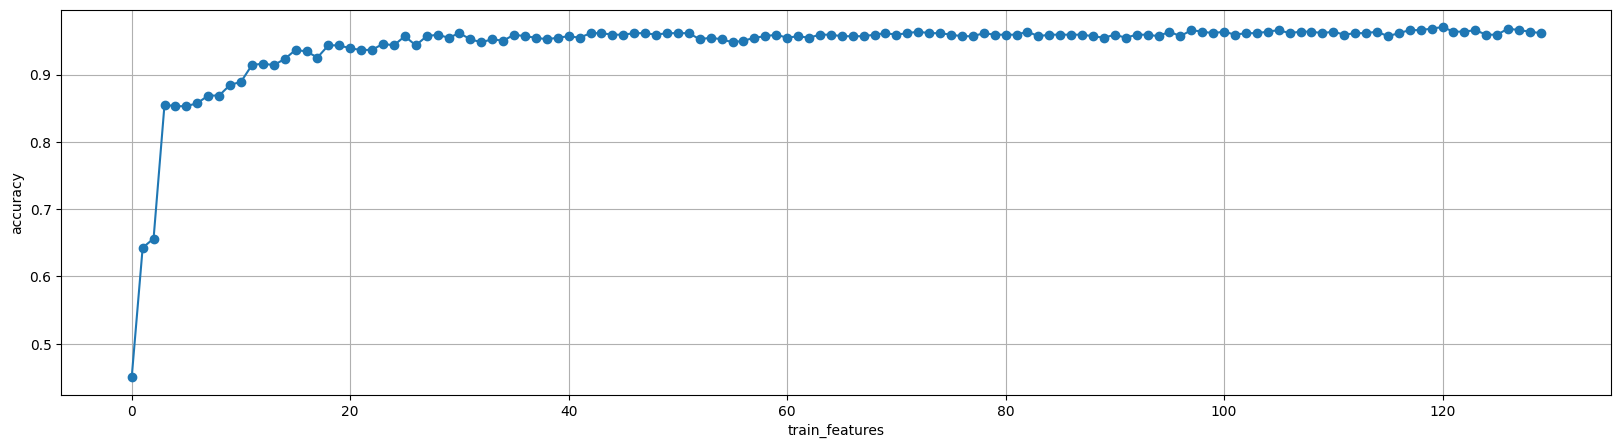

In [ ]:
# accuracy_score 누적한 acc 변수 시각화
## 참고 함수: plt.plot


* 정확도 최고의 학습 Feature 개수 찾기

In [ ]:
# acc 변수를 accuracy_score 기준 내림차순으로 정렬(인덱스 재설정X)
# accuracy_score 값이 가장 높을때의 인덱스명이 학습된 상위 feature 개수를 뜻함



,accuracy_score
120,0.970588
119,0.968326
126,0.968326
118,0.966063
123,0.966063
...,...
4,0.852941
5,0.852941
2,0.656109
1,0.642534


In [ ]:
# importance_top 변수에 acc 에서 확인한 상위 feature 개수 만큼 importance_sort['feature_name']를 슬라이싱 하여 할당
# 참고: 슬라이싱 할때 [:1] -> index 0 까지 짤림, [:100] -> index 99 까지 짤림, 정확도 최고치 인덱스 값 +1 해서 슬라이싱 할것


0               tBodyGyroJerk-mad()-X
1                    tBodyAcc-max()-X
2                fBodyAccJerk-std()-Y
3                angle(X,gravityMean)
4                tGravityAcc-mean()-X
                    ...              
116             tBodyGyro-entropy()-Z
117                  tBodyAcc-min()-Z
118         tGravityAcc-arCoeff()-Y,1
119                 fBodyGyro-iqr()-X
120    tBodyAccJerk-correlation()-X,Y
Name: feature_name, Length: 121, dtype: str

In [ ]:
# 훈련 데이터 생성
# x_train_top 변수에 X_train을 중요 feature 만클 슬라이싱 한 X_train[importance_top] 할당
# x_val_top 변수에 X_val을 중요 feature 만클 슬라이싱 한 X_val[importance_top] 할당



In [ ]:
# XGBClassifier 모델 초기화,학습,예측
# XGBClassifier 파라미터 : learning_rate=0.3, max_depth=3, random_state=2026
# AI모델 변수명: xgb_top_model , 예측결과 변수명: xgb_top_pred
# random_state=2026



array([1, 3, 3, 2, 1, 0, 2, 3, 3, 0, 5, 2, 4, 2, 1, 2, 4, 2, 1, 1, 0, 3,
       3, 0, 2, 0, 0, 4, 4, 4, 4, 3, 3, 3, 0, 5, 5, 3, 3, 5, 2, 2, 0, 0,
       3, 5, 0, 1, 4, 1, 0, 4, 3, 3, 4, 4, 5, 5, 4, 3, 2, 2, 3, 0, 5, 4,
       1, 1, 4, 0, 0, 2, 0, 4, 2, 3, 3, 1, 0, 3, 4, 1, 2, 4, 2, 0, 2, 1,
       4, 3, 1, 0, 2, 5, 4, 2, 0, 0, 4, 1, 5, 0, 0, 3, 3, 0, 3, 1, 5, 0,
       3, 0, 3, 0, 5, 2, 0, 0, 3, 3, 0, 2, 1, 1, 1, 5, 1, 5, 5, 1, 3, 0,
       3, 0, 5, 0, 3, 4, 2, 5, 0, 2, 4, 0, 4, 2, 5, 4, 1, 1, 5, 2, 3, 5,
       2, 0, 3, 4, 2, 4, 4, 3, 1, 0, 1, 2, 4, 2, 3, 0, 1, 3, 3, 4, 3, 3,
       4, 4, 4, 2, 0, 0, 2, 2, 5, 3, 3, 2, 4, 5, 0, 2, 2, 5, 4, 0, 3, 5,
       0, 5, 5, 5, 4, 5, 3, 2, 2, 2, 1, 3, 3, 4, 3, 3, 3, 4, 2, 3, 2, 2,
       5, 1, 2, 4, 4, 0, 5, 4, 0, 2, 2, 1, 0, 4, 4, 0, 3, 4, 1, 4, 3, 1,
       2, 0, 1, 3, 2, 0, 1, 4, 5, 2, 0, 1, 2, 3, 2, 5, 0, 2, 1, 4, 1, 1,
       4, 4, 2, 1, 2, 0, 1, 3, 1, 2, 0, 0, 0, 1, 0, 5, 2, 2, 0, 0, 3, 0,
       0, 4, 0, 2, 4, 4, 5, 1, 3, 2, 1, 2, 2, 2, 5,

In [ ]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)



accuracy_score:  0.9705882352941176

 confusion_matrix: 
 [[78  3  0  0  0  0]
 [ 4 64  0  0  0  0]
 [ 0  0 80  0  2  0]
 [ 0  0  0 74  1  0]
 [ 0  0  0  0 74  0]
 [ 0  0  0  2  1 59]]

 classification_report: 
               precision    recall  f1-score   support

           0       0.95      0.96      0.96        81
           1       0.96      0.94      0.95        68
           2       1.00      0.98      0.99        82
           3       0.97      0.99      0.98        75
           4       0.95      1.00      0.97        74
           5       1.00      0.95      0.98        62

    accuracy                           0.97       442
   macro avg       0.97      0.97      0.97       442
weighted avg       0.97      0.97      0.97       442



In [ ]:
# result 변수에 result 데이터프레임 마지막에 모델 평가 결과 추가 (append 함수는 inplace 파라미터가 없음)
# 할당할 정보는 데이터명('test'), 모델명('xgb_top'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 정확히 구성되었나 확인



,data,model_name,accuracy_score,f1_score
0,train,svc,0.968839,0.971715
1,train,knn,0.954674,0.958345
2,train,lr,0.983003,0.984583
3,train,gb,0.982436,0.983649
4,train,xgb,0.990368,0.991052
5,train,xgb_hpt,0.991501,0.992355
6,train,xgb95_hpt,0.992068,0.992371
7,train,xgb50_hpt,0.988669,0.988601
8,train,xgb_top,0.992635,0.993060
9,test,xgb_hpt,0.963801,0.963447


### (3) 결과 저장 및 시각화

In [ ]:
# 인덱스 미포함 result 변수를 result5.csv 파일로 저장
# 저장경로: ./data
# 파일명: result5.csv



In [ ]:
# 잘 저장 되었는지 확인




,data,model_name,accuracy_score,f1_score
0,train,svc,0.968839,0.971715
1,train,knn,0.954674,0.958345
2,train,lr,0.983003,0.984583
3,train,gb,0.982436,0.983649
4,train,xgb,0.990368,0.991052
5,train,xgb_hpt,0.991501,0.992355
6,train,xgb95_hpt,0.992068,0.992371
7,train,xgb50_hpt,0.988669,0.988601
8,train,xgb_top,0.992635,0.993060
9,test,xgb_hpt,0.963801,0.963447


*  model_name 별 accuracy_score, f1_score 시각화(수직 그래프) 

In [ ]:
# result_comp 변수에 result 데이터프레임의 data, model_name을 컴럼으로 지정 후 할당
# 참고함수: set_index
# 지정 인덱스: ['data','model_name']



accuracy_score  f1_score
data  model_name                          
train svc               0.968839  0.971715
      knn               0.954674  0.958345
      lr                0.983003  0.984583
      gb                0.982436  0.983649
      xgb               0.990368  0.991052
      xgb_hpt           0.991501  0.992355
      xgb95_hpt         0.992068  0.992371
      xgb50_hpt         0.988669  0.988601
      xgb_top           0.992635  0.993060
test  xgb_hpt           0.963801  0.963447
      xgb_top           0.970588  0.970313

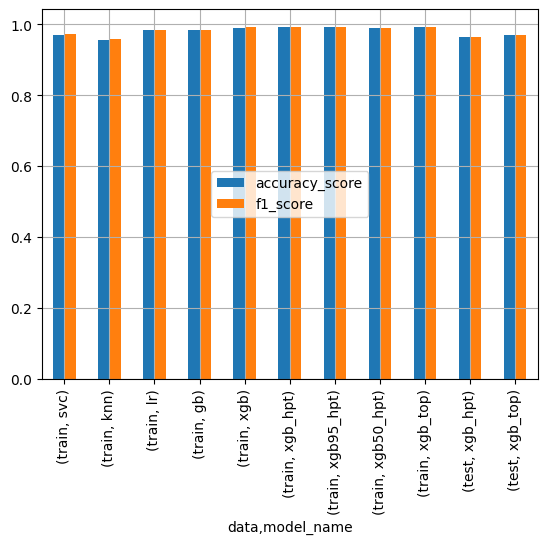

In [ ]:
# pandas의 plot 함수을 사용하여 AI모델 별 accuracy_score, f1_score 수직 그래프 시각화
# grid 추가
# legend 위치 center



---
---

# 미션6 : 행동 추론

### (0) 미션 이해하기
   * 단말기 개발팀에서 스마트워치에 헬스케어 기능을 추가 할 수 있도록, 스마트워치에서 수집하는 데이터를 분석해 행동을 분류할 수 있는 AI 모델과 중요 Future list를 전달해야 합니다.
   * test 데이터셋에서 6가지 행동분류 중 'WALKING_UPSTAIRS'를 분류하는 모델을 만들고 정확도 도출해 보세요.
   * 마지막으로 누적된 모델의 정확도(result)와 'WALKING_UPSTAIRS' 행동분류 중요 Feature 5개의 정보를 개발팀으로 전달해 주세요.
   

<span style="background-color:#fff5b1"><span style="color:black"><U>※ 미션완수 조건: 헬스케어 기능 개발을 위해 '계단 오르기' 행동분류를 위한 모델을 만들고 정확도와 데이터를 시각화 하세요.<U></span></span>

### (1) 데이터 불러오기

	- 실습순서: 라이브러리 불러오기 -> 현재 디렉토리 확인 -> train_data.csv 불러오기 -> 'subject' 제거 -> result5.csv 불러오기

In [29]:
# pandas, numpy, matplotlib, seaborn, os 등 필요 라이브러리 호출
# 데이터를 나누기 위한 sklearn.model_selection 모듈의 train_test_split 함수 사용
# 모델 성능 평가 출력을 위해 sklearn.metrics 모듈의 모든 클래스 사용

import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

* test 데이터 불러오기

In [ ]:
# 'data' 폴더에서 test_data.csv 파일을 불러와서 data 변수에 할당
# 잘 할당 되었는지 상위 5개행 데이터 확인



,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.284379,-0.021981,-0.116683,-0.992490,-0.979640,-0.963321,-0.992563,-0.977304,-0.958142,-0.938850,...,-0.850065,-0.018043,0.092304,0.074220,-0.714534,-0.671943,-0.018351,-0.185733,22,SITTING
1,0.277440,-0.028086,-0.118412,-0.996620,-0.927676,-0.972294,-0.997346,-0.931405,-0.971788,-0.939837,...,-0.613367,-0.022456,-0.155414,0.247498,-0.112257,-0.826816,0.184489,-0.068699,15,STANDING
2,0.305833,-0.041023,-0.087303,0.006880,0.182800,-0.237984,0.005642,0.028616,-0.236474,0.016311,...,0.394388,-0.362616,0.171069,0.576349,-0.688314,-0.743234,0.272186,0.053101,22,WALKING
3,0.276053,-0.016487,-0.108381,-0.995379,-0.983978,-0.975854,-0.995877,-0.985280,-0.974907,-0.941425,...,-0.841455,0.289548,0.079801,-0.020033,0.291898,-0.639435,-0.111998,-0.123298,8,SITTING
4,0.271998,0.016904,-0.078856,-0.973468,-0.702462,-0.869450,-0.979810,-0.711601,-0.856807,-0.920760,...,0.214219,0.010111,0.114179,-0.830776,-0.325098,-0.840817,0.116237,-0.096615,5,STANDING


In [ ]:
# data 변수(데이터셋)에서 행동분류에 불필요한 'subject'열 제거
# 'subject'열이 잘 제거 되었는지 확인



,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.284379,-0.021981,-0.116683,-0.992490,-0.979640,-0.963321,-0.992563,-0.977304,-0.958142,-0.938850,...,-0.509523,-0.850065,-0.018043,0.092304,0.074220,-0.714534,-0.671943,-0.018351,-0.185733,SITTING
1,0.277440,-0.028086,-0.118412,-0.996620,-0.927676,-0.972294,-0.997346,-0.931405,-0.971788,-0.939837,...,-0.210792,-0.613367,-0.022456,-0.155414,0.247498,-0.112257,-0.826816,0.184489,-0.068699,STANDING
2,0.305833,-0.041023,-0.087303,0.006880,0.182800,-0.237984,0.005642,0.028616,-0.236474,0.016311,...,0.579587,0.394388,-0.362616,0.171069,0.576349,-0.688314,-0.743234,0.272186,0.053101,WALKING
3,0.276053,-0.016487,-0.108381,-0.995379,-0.983978,-0.975854,-0.995877,-0.985280,-0.974907,-0.941425,...,-0.566291,-0.841455,0.289548,0.079801,-0.020033,0.291898,-0.639435,-0.111998,-0.123298,SITTING
4,0.271998,0.016904,-0.078856,-0.973468,-0.702462,-0.869450,-0.979810,-0.711601,-0.856807,-0.920760,...,0.447577,0.214219,0.010111,0.114179,-0.830776,-0.325098,-0.840817,0.116237,-0.096615,STANDING
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466,0.278725,-0.015262,-0.106398,-0.993625,-0.982845,-0.974745,-0.993963,-0.981100,-0.974596,-0.939303,...,-0.586580,-0.874066,-0.054788,0.712975,0.300318,-0.319188,-0.857336,0.120184,0.119276,SITTING
1467,0.275803,-0.019257,-0.109078,-0.998614,-0.991621,-0.987403,-0.998813,-0.991503,-0.986802,-0.945442,...,-0.451941,-0.721050,0.076333,-0.021599,-0.277268,0.754011,-0.764185,0.212111,0.138595,STANDING
1468,0.240402,0.006361,-0.121377,-0.045805,0.189930,0.332664,-0.114706,0.157771,0.195271,0.210139,...,-0.213340,-0.615554,0.330378,-0.667635,0.806563,-0.850113,-0.639564,0.185363,0.260201,WALKING_DOWNSTAIRS
1469,0.135873,-0.020675,-0.116644,-0.960526,-0.955134,-0.985818,-0.963115,-0.971338,-0.988261,-0.946289,...,0.072602,-0.422383,-0.048474,0.236761,-0.186581,0.396648,0.790877,-0.474618,-0.505953,LAYING


* result 데이터 불러오기

In [ ]:
# 모델별 정확도를 비교 할 수 있도록 결과 저장 파일 호출 
# result 변수에 'data' 폴더에서 /result5.csv 파일을 불러와서 할당
# 잘 불러와 졌는지 확인


,data,model_name,accuracy_score,f1_score
0,train,svc,0.968839,0.971715
1,train,knn,0.954674,0.958345
2,train,lr,0.983003,0.984583
3,train,gb,0.982436,0.983649
4,train,xgb,0.990368,0.991052
5,train,xgb_hpt,0.991501,0.992355
6,train,xgb95_hpt,0.992068,0.992371
7,train,xgb50_hpt,0.988669,0.988601
8,train,xgb_top,0.992635,0.993060
9,test,xgb_hpt,0.963801,0.963447


### (2) 'WALKING_UPSTAIRS' 행동분류에 사용할 feature 중요도 도출을 위한 모델링
* 'WALKING_UPSTAIRS' 행동분류의 feature 중요도를 도출하기 전 사전 모델링을 시행 하세요


	- 실습순서: 라이브러리 호출-> 데이터 분할 -> 데이터 가공 -> 모델링 -> 결과 출력

In [ ]:
# XGBClassifier 알고리즘 사용을 위한 모듈 추가
# GridSearchCV 모듈을 사용하기 위한 모듈 추가(scikit-learn 라이브러리에 포함)



In [ ]:
# X, y 데이터 나누기 (target = 'Activity')



* 'WALKING_UPSTAIRS' 분류를 위한 맵핑

In [ ]:
# XGBoost 는 문자형 데이터로 학습할 수 없습니다. 
# y_map 변수를 생성해서 target 데이터(y)를 숫자형 형태로 치환하여 할당
# 데이터 치환 함수: map
# 치환 데이터: 'STANDING':0, 'SITTING':0, 'LAYING':0, 'WALKING':0, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':0



0       0
1       0
2       0
3       0
4       0
       ..
1466    0
1467    0
1468    0
1469    0
1470    0
Name: Activity, Length: 1471, dtype: int64

In [ ]:
# X,y_map를 사용하여 학습 데이터 분할 비율: 학습데이터 7 : 검증데이터 3
# random_state=2026


* 'WALKING_UPSTAIRS' 행동분류 모델링

In [ ]:
# 베스트 파라미터를 적용한 xgb 모델 초기화, 학습, 예측
# AI모델 변수명: up_xgb_model 예측결과 변수명: up_xgb_pred
# random_state=2026



array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)




accuracy_score:  0.9864253393665159

 confusion_matrix: 
 [[367   1]
 [  5  69]]

 classification_report: 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       368
           1       0.99      0.93      0.96        74

    accuracy                           0.99       442
   macro avg       0.99      0.96      0.98       442
weighted avg       0.99      0.99      0.99       442



In [ ]:
# result 변수에 result 변수(데이터프레임) 마지막에 모델 평가 결과 추가 
# 할당할 정보는 데이터명('test'), 모델명('up_xgb'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 정확히 구성되었나 확인



,data,model_name,accuracy_score,f1_score
0,train,svc,0.968839,0.971715
1,train,knn,0.954674,0.958345
2,train,lr,0.983003,0.984583
3,train,gb,0.982436,0.983649
4,train,xgb,0.990368,0.991052
5,train,xgb_hpt,0.991501,0.992355
6,train,xgb95_hpt,0.992068,0.992371
7,train,xgb50_hpt,0.988669,0.988601
8,train,xgb_top,0.992635,0.993060
9,test,xgb_hpt,0.963801,0.963447


### (3) 'WORKING_UPSTAIRS' 행동분류 모델 Feature Selection
* WORKING_UPSTAIRS을 분류한 모델에 영향을 미친 중요 feature를 찾고 상위 5개 feature의 데이터에 대해 시각화를 합니다.

	- 실습순서: 중요도 데이터프레임 생성-> 데이터 분할/가공 -> 최적의 Feature Selection 찾기 -> 상위 5개 feature 데이터 시각화 -> 센서별 중요도 시각화 

* 변수별 중요도 추출

In [ ]:
# importance_sort 데이터프레임 변수 생성 초기화



""


In [ ]:
# importance_sort['feature_name'] 열에 모델링에 사용한 X 데이터프레임의 컬럼명을 할당



,feature_name
0,tBodyAcc-mean()-X
1,tBodyAcc-mean()-Y
2,tBodyAcc-mean()-Z
3,tBodyAcc-std()-X
4,tBodyAcc-std()-Y
...,...
556,"angle(tBodyGyroMean,gravityMean)"
557,"angle(tBodyGyroJerkMean,gravityMean)"
558,"angle(X,gravityMean)"
559,"angle(Y,gravityMean)"


In [ ]:
# importance_sort['feature_importance'] 열에 앞에서 사용한 xgb_hpt_up_model 모델의 feature_importances 를 할당
# 참고함수: feature_importances_



,feature_name,feature_importance
0,tBodyAcc-mean()-X,0.000000
1,tBodyAcc-mean()-Y,0.000000
2,tBodyAcc-mean()-Z,0.000000
3,tBodyAcc-std()-X,0.009709
4,tBodyAcc-std()-Y,0.000000
...,...,...
556,"angle(tBodyGyroMean,gravityMean)",0.000194
557,"angle(tBodyGyroJerkMean,gravityMean)",0.000000
558,"angle(X,gravityMean)",0.000000
559,"angle(Y,gravityMean)",0.000576


In [ ]:
# importance_sort['feature_importance'] 를 내림차순 정열(기준열='feature_importance', 내림차순)
# 참고함수: sort_values



,feature_name,feature_importance
316,"fBodyAcc-bandsEnergy()-1,8.1",0.190646
233,tBodyAccJerkMag-iqr(),0.144132
201,tBodyAccMag-std(),0.106992
75,"tGravityAcc-arCoeff()-Z,3",0.099918
57,tGravityAcc-energy()-Y,0.056426
...,...,...
46,tGravityAcc-mad()-X,0.000000
557,"angle(tBodyGyroJerkMean,gravityMean)",0.000000
558,"angle(X,gravityMean)",0.000000
47,tGravityAcc-mad()-Y,0.000000


In [ ]:
# feature_importance 내림차순 정렬 때문에 엉킨 인덱스 재설정
# 참고함수: reset_index
# 파라미터: drop=True, inplace=True
# 제대로 정렬 되었는지 데이터 프레임에 확인



,feature_name,feature_importance
0,"fBodyAcc-bandsEnergy()-1,8.1",0.190646
1,tBodyAccJerkMag-iqr(),0.144132
2,tBodyAccMag-std(),0.106992
3,"tGravityAcc-arCoeff()-Z,3",0.099918
4,tGravityAcc-energy()-Y,0.056426
...,...,...
556,tGravityAcc-mad()-X,0.000000
557,"angle(tBodyGyroJerkMean,gravityMean)",0.000000
558,"angle(X,gravityMean)",0.000000
559,tGravityAcc-mad()-Y,0.000000


* Feature Selection 을 반복적으로 적용해 최고 정확도의 중요 feature 개수 학습 결과 선별

In [ ]:
# acc 데이터 프레임을 생성 및 초기화(컬럼 지정: columns=['accuracy_score'])
# for 문을 사용해 중요도 상위 feature 1개 모델링부터 상위 feature 130개  모델링까지 순차적 모델링 실행 후 각 accuracy_score 결과를 acc 변수에 누적
# 전체 feature는 561개 이지만, 학습에 130개면 충분(약 10분 소요)
# for 매 회 마다 결과 출력

acc = pd.DataFrame(columns=['accuracy_score'])



accuracy_score    0.828054
Name: 0, dtype: float64
accuracy_score    0.909502
Name: 1, dtype: float64
accuracy_score    0.929864
Name: 2, dtype: float64
accuracy_score    0.970588
Name: 3, dtype: float64
accuracy_score    0.977376
Name: 4, dtype: float64
accuracy_score    0.979638
Name: 5, dtype: float64
accuracy_score    0.9819
Name: 6, dtype: float64
accuracy_score    0.979638
Name: 7, dtype: float64
accuracy_score    0.986425
Name: 8, dtype: float64
accuracy_score    0.984163
Name: 9, dtype: float64
accuracy_score    0.988688
Name: 10, dtype: float64
accuracy_score    0.984163
Name: 11, dtype: float64
accuracy_score    0.986425
Name: 12, dtype: float64
accuracy_score    0.988688
Name: 13, dtype: float64
accuracy_score    0.986425
Name: 14, dtype: float64
accuracy_score    0.984163
Name: 15, dtype: float64
accuracy_score    0.988688
Name: 16, dtype: float64
accuracy_score    0.986425
Name: 17, dtype: float64
accuracy_score    0.986425
Name: 18, dtype: float64
accuracy_score    0.9886

,accuracy_score
0,0.828054
1,0.909502
2,0.929864
3,0.970588
4,0.977376
...,...
125,0.986425
126,0.986425
127,0.988688
128,0.988688


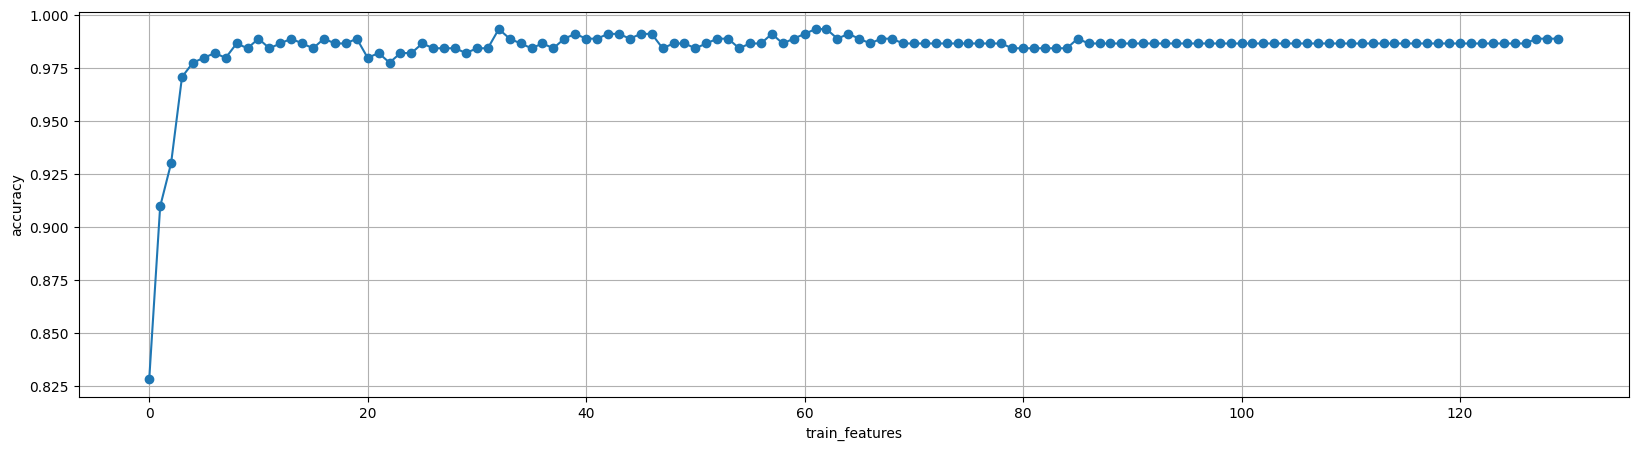

In [ ]:
# accuracy_score 누적한 acc 변수 시각화
## 참고 함수: plt.plot



* 정확도 최고의 학습 Feature 개수 찾기

In [ ]:
# acc 변수를 accuracy_score 기준 내림차순으로 정렬(인덱스 재설정X)
# 이 코드에서는 인덱스가 accuracy_score 값이 높을때의 인덱스명이 학습된 상위 feature의 개수를 뜻함



,accuracy_score
61,0.993213
32,0.993213
62,0.993213
64,0.990950
42,0.990950
...,...
22,0.977376
3,0.970588
2,0.929864
1,0.909502


In [ ]:
# importance_top 변수에 acc 에서 확인한 상위 feature 개수 만큼 importance_sort['feature_name']를 슬라이싱 하여 할당
# 참고: 슬라이싱 할때 [:1] -> index 0 까지 짤림, [:100] -> index 99 까지 짤림, 정확도 최고치 인덱스 값 +1 해서 슬라이싱 할것



0     fBodyAcc-bandsEnergy()-1,8.1
1            tBodyAccJerkMag-iqr()
2                tBodyAccMag-std()
3        tGravityAcc-arCoeff()-Z,3
4           tGravityAcc-energy()-Y
                  ...             
57       tGravityAcc-arCoeff()-Y,4
58          tBodyGyroJerk-mean()-Z
59           fBodyAcc-skewness()-Y
60     tBodyGyro-correlation()-X,Z
61      tBodyAccJerk-arCoeff()-Z,1
Name: feature_name, Length: 62, dtype: str

In [ ]:
# 훈련 데이터 생성
# x_train_top 변수에 X_train을 중요 feature 만클 슬라이싱 한 X_train[importance_top] 할당
# x_val_top 변수에 X_val을 중요 feature 만클 슬라이싱 한 X_val[importance_top] 할당


In [ ]:
# XGBClassifier 모델 초기화,학습,예측
# AI모델 변수명: up_xgb_top_model , 예측결과 변수명: up_xgb_top_pred
# random_state=2026



array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)



accuracy_score:  0.9932126696832579

 confusion_metrix: 
 [[368   0]
 [  3  71]]

 classification_report: 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       368
           1       1.00      0.96      0.98        74

    accuracy                           0.99       442
   macro avg       1.00      0.98      0.99       442
weighted avg       0.99      0.99      0.99       442



In [ ]:
# result 변수에 result 변수(데이터프레임) 마지막에 모델 평가 결과 추가 
# 할당할 정보는 데이터명('test'), 모델명('up_xgb_top'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 정확히 구성되었나 확인



,data,model_name,accuracy_score,f1_score
0,train,svc,0.968839,0.971715
1,train,knn,0.954674,0.958345
2,train,lr,0.983003,0.984583
3,train,gb,0.982436,0.983649
4,train,xgb,0.990368,0.991052
5,train,xgb_hpt,0.991501,0.992355
6,train,xgb95_hpt,0.992068,0.992371
7,train,xgb50_hpt,0.988669,0.988601
8,train,xgb_top,0.992635,0.993060
9,test,xgb_hpt,0.963801,0.963447


* 상위 5 feature의 데이터 저장 및 시각화 

In [ ]:
# 상위 1~5위 feature_name 확인


0    fBodyAcc-bandsEnergy()-1,8.1
1           tBodyAccJerkMag-iqr()
2               tBodyAccMag-std()
3       tGravityAcc-arCoeff()-Z,3
4          tGravityAcc-energy()-Y
Name: feature_name, dtype: str

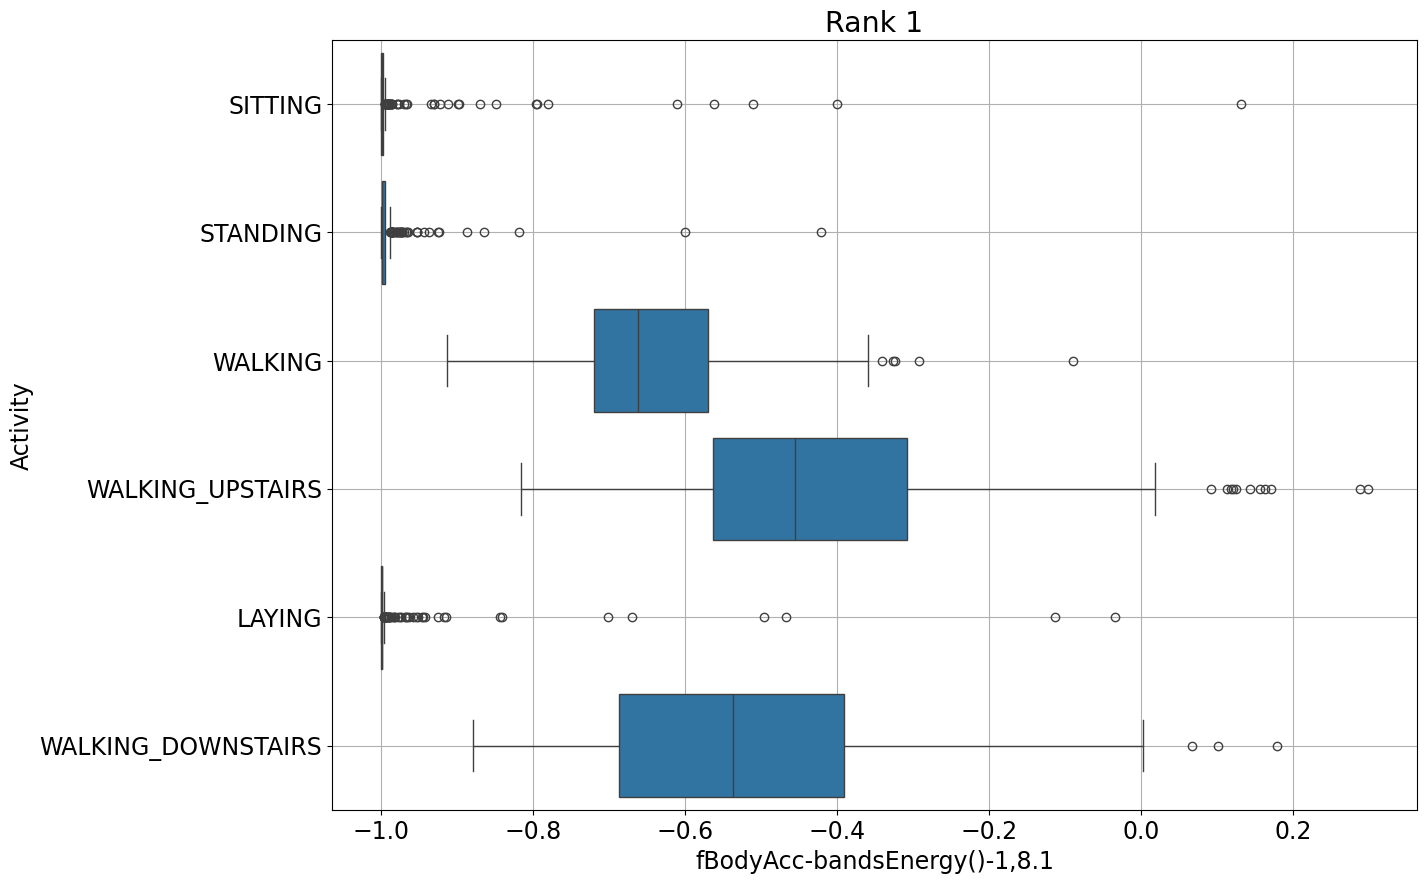

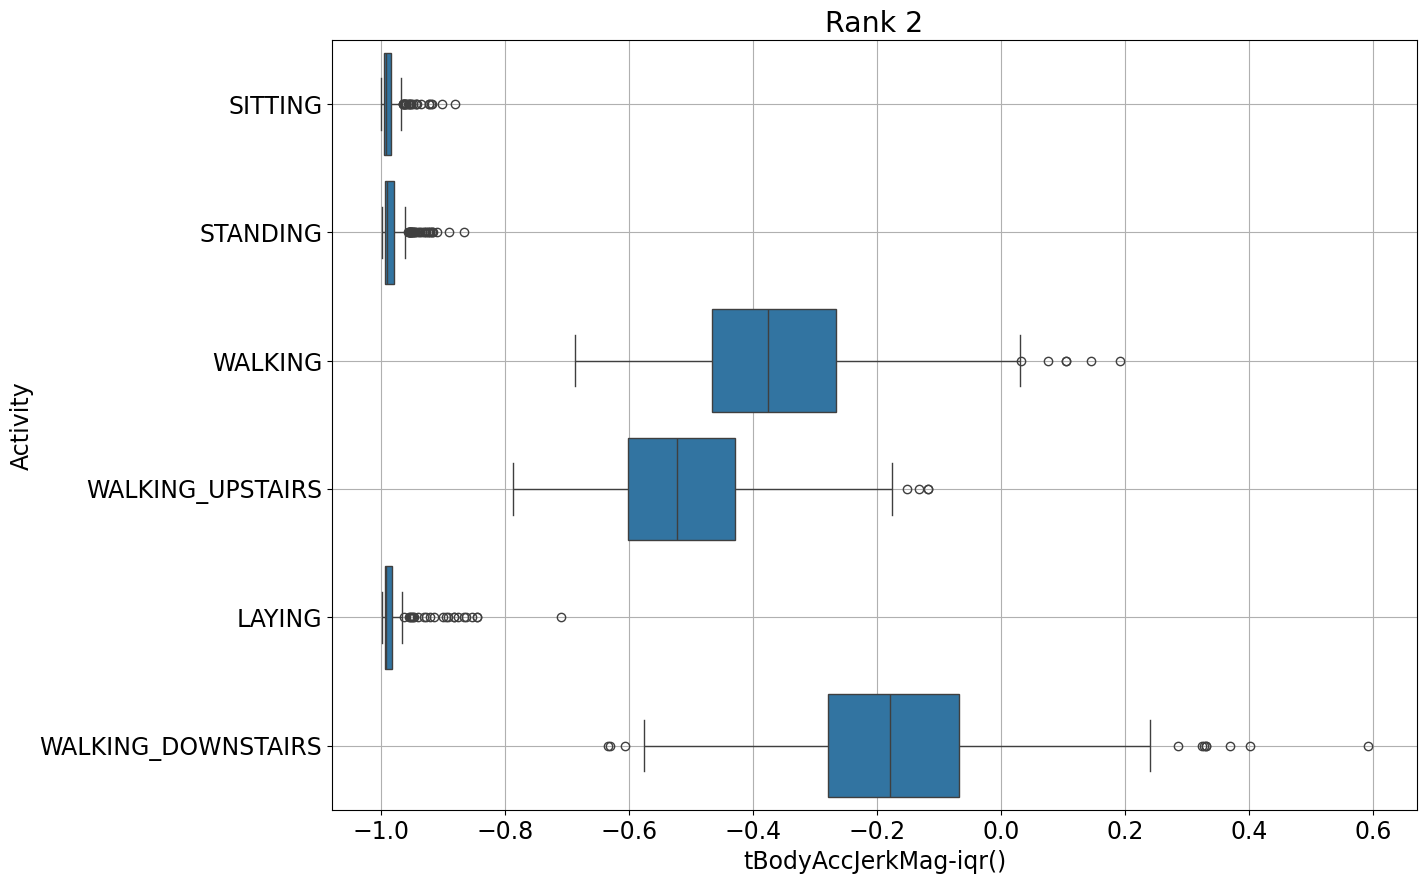

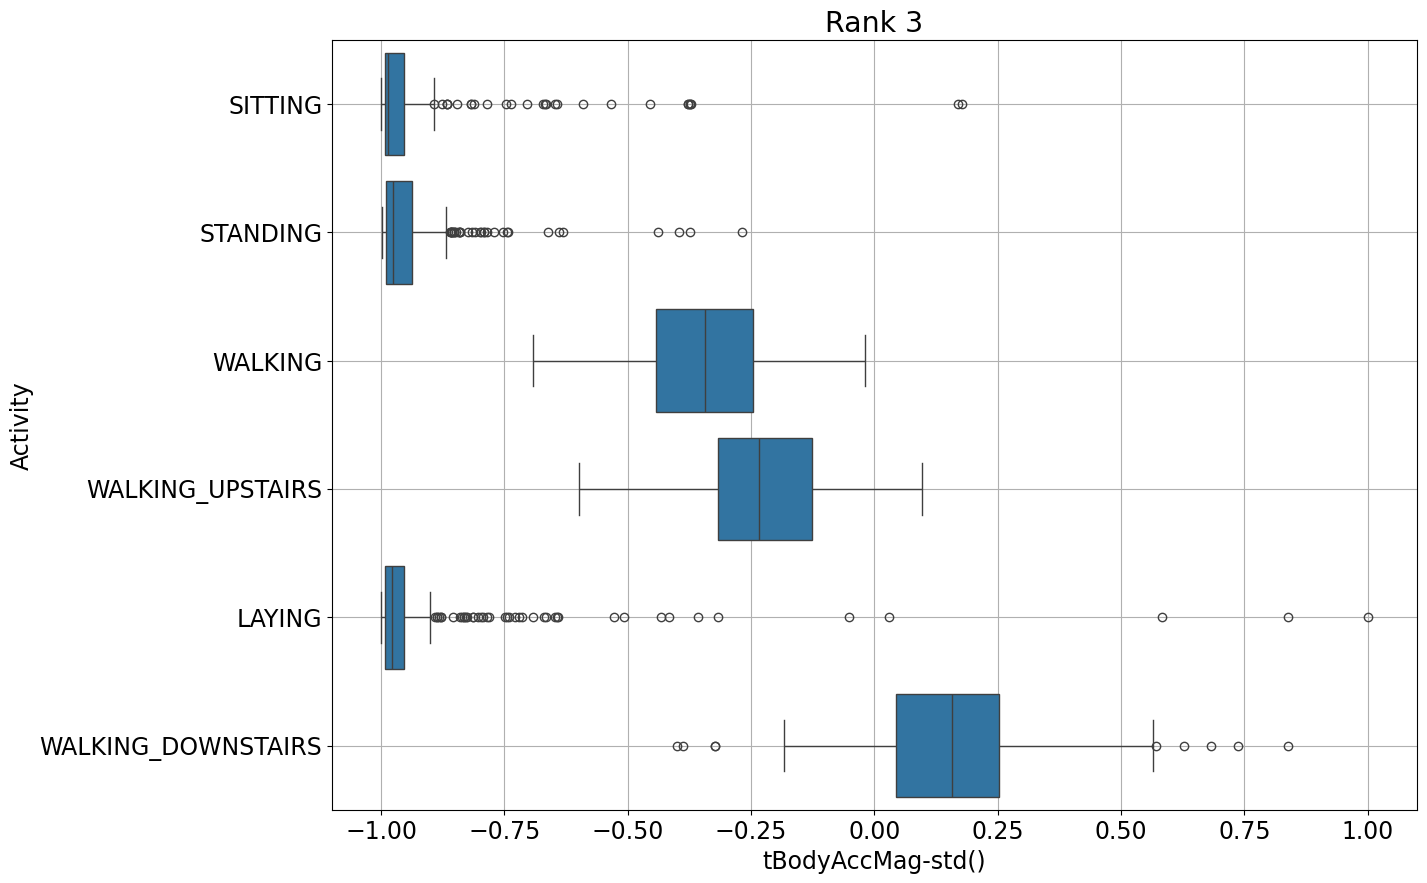

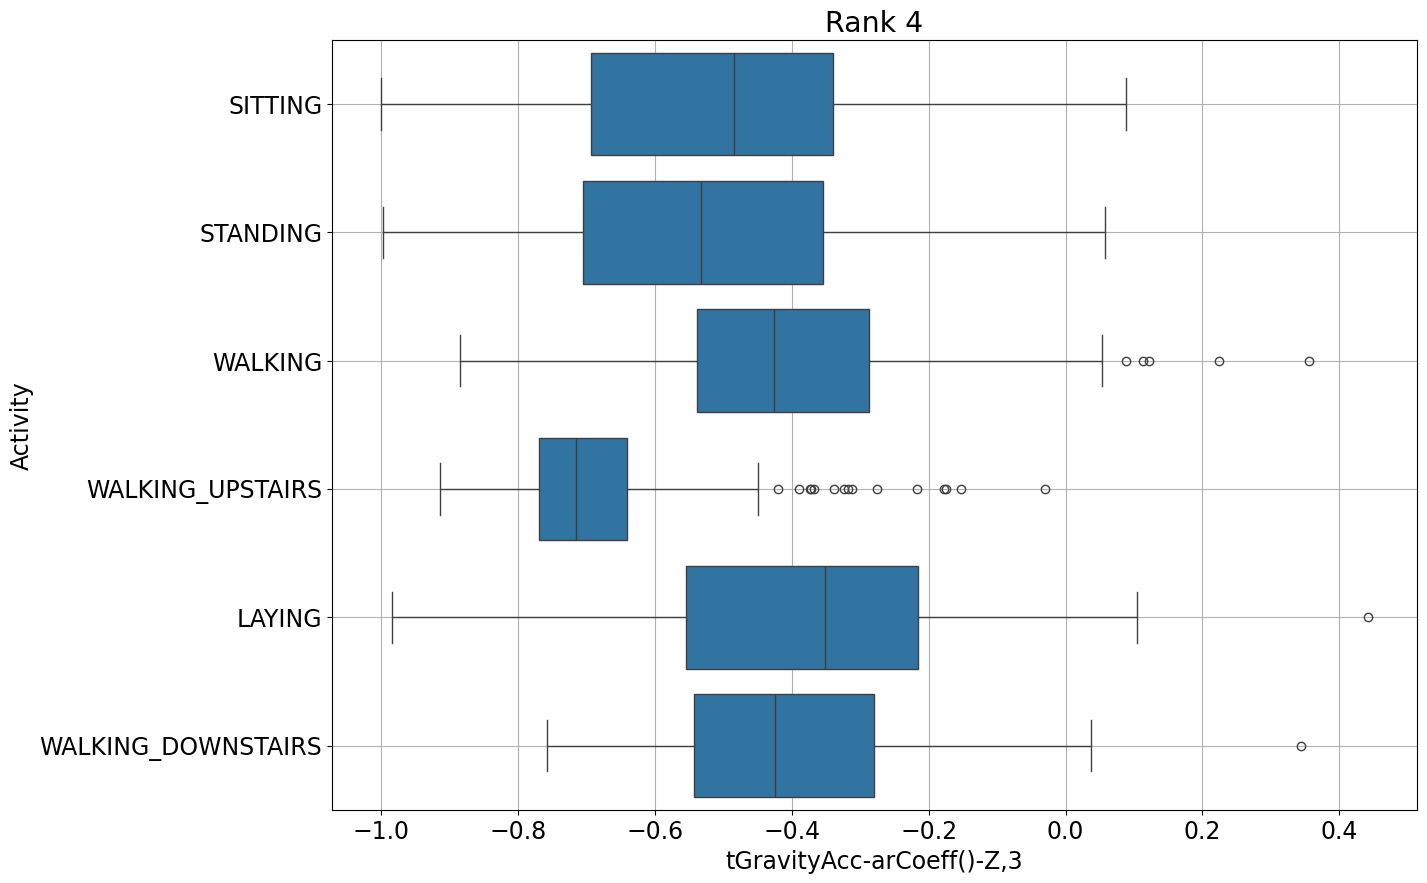

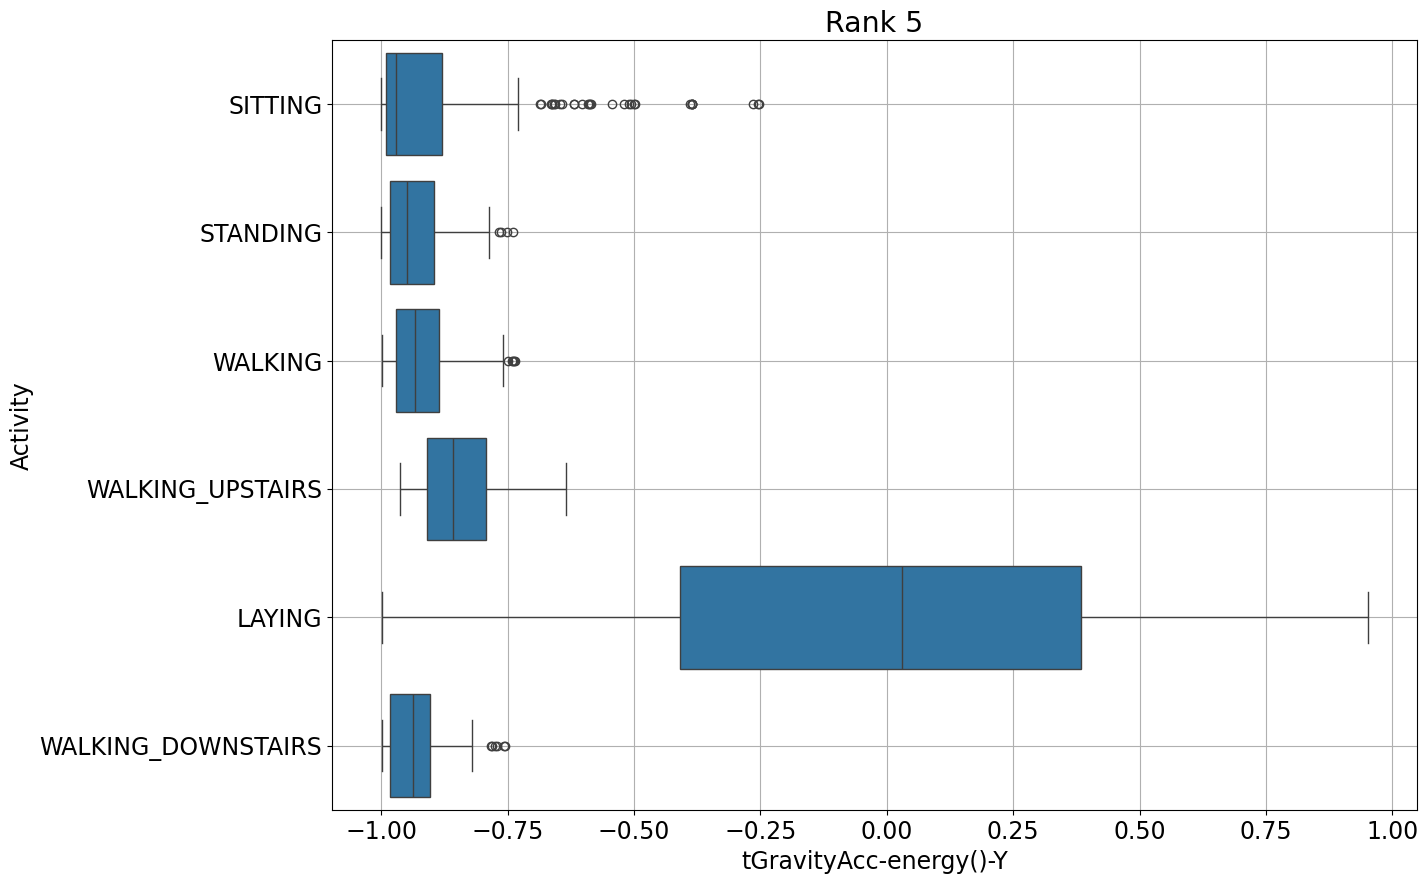

In [ ]:
# 상위 1~5위 feature에 대한 BoxPlot 그래프 그리기


In [ ]:
# 상위 1~5 순위 feature 파일로 저장
# 저장경로: ./
# 파일명: importance_result.csv



### (4) 'WORKING_UPSTAIRS' 분류에 영향을 미치는 'sensor' 찾기
* 'WORKING_UPSTAIRS' 분류에 영향을 미치는 'sensor' 별, 'sensor + agg' 별, 'sensor 하위 agg 그룹의 누적' 그래프를 그려보세요.

	- 실습순서: 센서 데이터 불러오기 -> 데이터 프레임 merge 하기 -> sensor 별 중요도 시각화  -> agg 별 상위 20 중요도 시각화 -> sensor 별 agg 중요도 누적 그래프 시각화

* features 데이터 불러오기

In [ ]:
# feature_group 변수를 생성하여 하위 data 폴더의 features.csv 데이터셋 할당
# 데이터가 잘 할당 되었나 features 데이터 확인



,sensor,agg,axis,feature_name
0,tBodyAcc,mean(),X,tBodyAcc-mean()-X
1,tBodyAcc,mean(),Y,tBodyAcc-mean()-Y
2,tBodyAcc,mean(),Z,tBodyAcc-mean()-Z
3,tBodyAcc,std(),X,tBodyAcc-std()-X
4,tBodyAcc,std(),Y,tBodyAcc-std()-Y
...,...,...,...,...
556,angle,tBodyGyroMean,gravityMean,"angle(tBodyGyroMean,gravityMean)"
557,angle,tBodyGyroJerkMean,gravityMean,"angle(tBodyGyroJerkMean,gravityMean)"
558,angle,X,gravityMean,"angle(X,gravityMean)"
559,angle,Y,gravityMean,"angle(Y,gravityMean)"


* merge_df 데이터프레임 만들기

In [ ]:
# merge_df 데이터프레임 변수 생성 및 초기화
# merge_df 변수에 feature_group 데이터프레임과 importance_sort 데이터프레임을 merge 하여 할당
# 데이터가 잘 할당 되었나 merge_df 데이터 확인



,sensor,agg,axis,feature_name,feature_importance
0,tBodyAcc,mean(),X,tBodyAcc-mean()-X,0.000000
1,tBodyAcc,mean(),Y,tBodyAcc-mean()-Y,0.000000
2,tBodyAcc,mean(),Z,tBodyAcc-mean()-Z,0.000000
3,tBodyAcc,std(),X,tBodyAcc-std()-X,0.009709
4,tBodyAcc,std(),Y,tBodyAcc-std()-Y,0.000000
...,...,...,...,...,...
556,angle,tBodyGyroMean,gravityMean,"angle(tBodyGyroMean,gravityMean)",0.000194
557,angle,tBodyGyroJerkMean,gravityMean,"angle(tBodyGyroJerkMean,gravityMean)",0.000000
558,angle,X,gravityMean,"angle(X,gravityMean)",0.000000
559,angle,Y,gravityMean,"angle(Y,gravityMean)",0.000576


* sensor 별 중요도 구하기

In [ ]:
# sensor_sum 데이터프레임 변수 생성 및 초기화
# sensor_sum 변수를 생성하여 merge_df 변수를 'sensor' 컬럼으로 그룹화 하고 하위 feature의  'feature_importance' 데이터를 더함
# 참고함수: groupby, sum
# 잘 더해졌나 sensor_sum 데이터 확인



sensor
angle                   0.000770
fBodyAcc                0.327714
fBodyAccJerk            0.030010
fBodyAccMag             0.010806
fBodyBodyAccJerkMag     0.020596
fBodyBodyGyroJerkMag    0.000105
fBodyBodyGyroMag        0.004517
fBodyGyro               0.045537
tBodyAcc                0.020995
tBodyAccJerk            0.013822
tBodyAccJerkMag         0.176684
tBodyAccMag             0.106992
tBodyGyro               0.015172
tBodyGyroJerk           0.002173
tBodyGyroJerkMag        0.000000
tBodyGyroMag            0.000256
tGravityAcc             0.224239
tGravityAccMag          0.000000
Name: feature_importance, dtype: float32

In [ ]:
# sensor_sort 변수를 생성하여 sensor_sum 데이터를 'feature_importance' 기준으로 내림차순 정렬 후 할당
# 참고함수: sort_values
# 파라미터: ascending=False
# 잘 정렬 되었는지 sensor_sort 데이터 확인



sensor
fBodyAcc                0.327714
tGravityAcc             0.224239
tBodyAccJerkMag         0.176684
tBodyAccMag             0.106992
fBodyGyro               0.045537
fBodyAccJerk            0.030010
tBodyAcc                0.020995
fBodyBodyAccJerkMag     0.020596
tBodyGyro               0.015172
tBodyAccJerk            0.013822
fBodyAccMag             0.010806
fBodyBodyGyroMag        0.004517
tBodyGyroJerk           0.002173
angle                   0.000770
tBodyGyroMag            0.000256
fBodyBodyGyroJerkMag    0.000105
tBodyGyroJerkMag        0.000000
tGravityAccMag          0.000000
Name: feature_importance, dtype: float32

* sensor 중요도 시각화

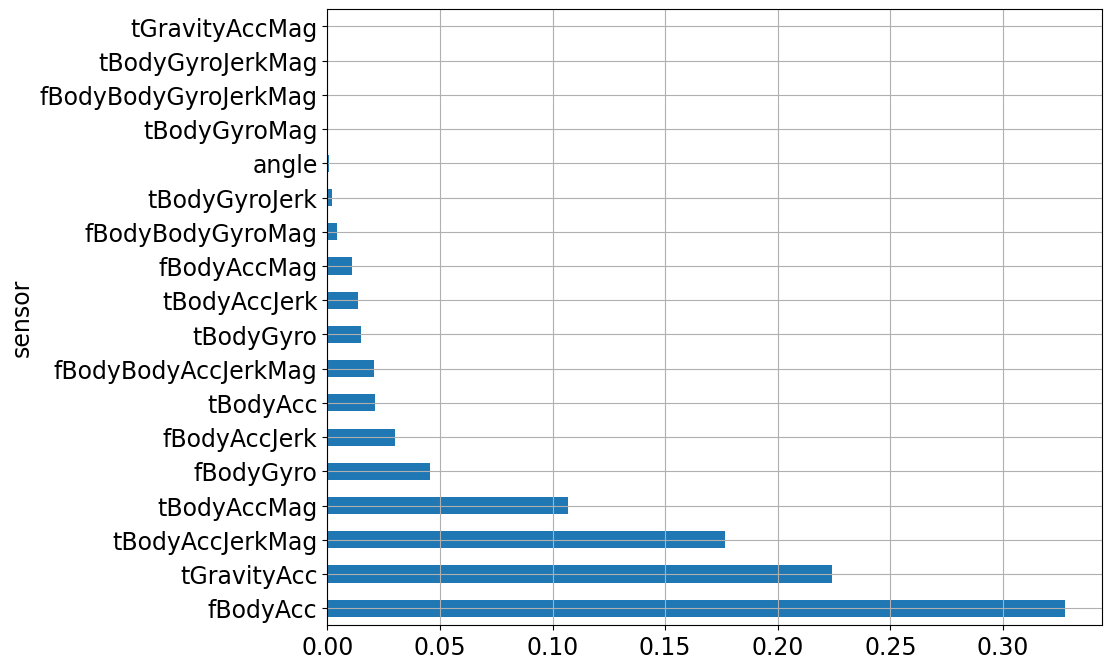

In [ ]:
# pandas의 plot 함수을 사용하여 sensor 별 중요도 시각화
# 참고함수: barh


* agg 별 상위 20 중요도 시각화

In [ ]:
# sensor_agg_sum 변수에 merge_df 변수를 ['sensor','agg'] 컬럼으로 그룹화 하고 하위 feature의  'feature_importance' 데이터를 더함



sensor          agg             
angle           X                   0.000000
                Y                   0.000576
                Z                   0.000000
                tBodyAccJerkMean    0.000000
                tBodyAccMean        0.000000
                                      ...   
tGravityAccMag  max()               0.000000
                mean()              0.000000
                min()               0.000000
                sma()               0.000000
                std()               0.000000
Name: feature_importance, Length: 221, dtype: float32

In [ ]:
# sensor_agg_sort 변수에 sensor_agg_sum  변수를 내림차순으로 정렬 후 할당



sensor           agg          
fBodyAcc         bandsEnergy()    0.250177
tBodyAccJerkMag  iqr()            0.144132
tGravityAcc      arCoeff()        0.141363
tBodyAccMag      std()            0.106992
tGravityAcc      energy()         0.058046
                                    ...   
tGravityAccMag   max()            0.000000
                 mean()           0.000000
                 min()            0.000000
                 sma()            0.000000
                 std()            0.000000
Name: feature_importance, Length: 221, dtype: float32

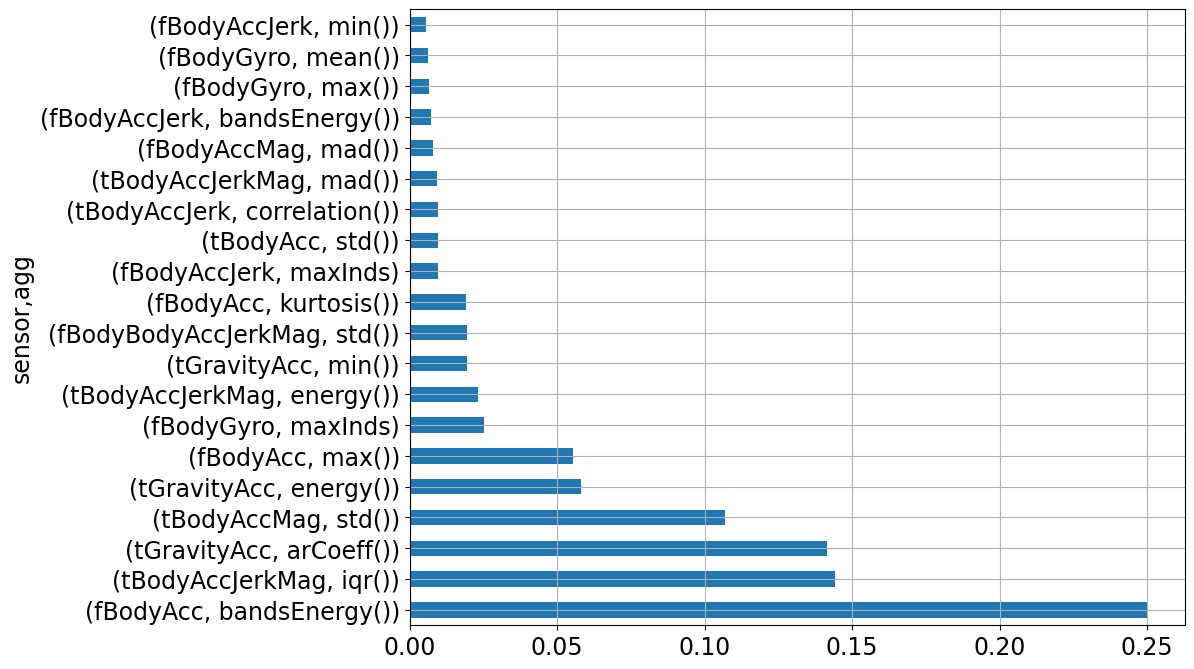

In [ ]:
# pandas의 plot 함수을 사용하여 sensor_agg_sort를 sensor 별 중요도 상위 20개만 시각화
# 참고함수: 변수명.plot
# 파라미터: kind='barh'


* sensor 별 agg 중요도 누적 그래프 시각화

In [ ]:
# acc변수에 sensor_agg_sort 변수의 'agg' 인덱스를 feature로 변환(재구조화) 후 할당
# 참고함수: unstack()



agg,X,Y,Z,arCoeff(),arCoeff()1,arCoeff()2,arCoeff()3,arCoeff()4,bandsEnergy(),correlation(),...,mean(),meanFreq(),min(),skewness(),sma(),std(),tBodyAccJerkMean,tBodyAccMean,tBodyGyroJerkMean,tBodyGyroMean
sensor,,,,,,,,,,,,,,,,,,,,,
angle,0.0,0.000576,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000194
fBodyAcc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.250177,NaN,...,0.000000,0.002249,0.000000,0.000747,0.0,0.000000,NaN,NaN,NaN,NaN
fBodyAccJerk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007227,NaN,...,0.000000,0.004212,0.005402,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN
fBodyAccMag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN
fBodyBodyAccJerkMag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.0,0.019423,NaN,NaN,NaN,NaN
fBodyBodyGyroJerkMag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000105,0.000000,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN
fBodyBodyGyroMag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.004343,0.000000,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN
fBodyGyro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001419,NaN,...,0.006338,0.004690,0.000000,0.001243,0.0,0.000083,NaN,NaN,NaN,NaN
tBodyAcc,NaN,NaN,NaN,0.000996,NaN,NaN,NaN,NaN,NaN,0.001810,...,0.000000,NaN,0.000000,NaN,0.0,0.009709,NaN,NaN,NaN,NaN


In [ ]:
# acc에 acc['sort']열을 생성하여 각 센서 별 데이터 값을 더한 값을 할당(센서명으로 나누어 더해 주어야 하기때문에 axis=1 파라미터를 추가한다.)
# acc['sort']열을 내림차순으로 정렬
# 참고함수: sort_values()
# 합계 및 정렬 확인



agg,X,Y,Z,arCoeff(),arCoeff()1,arCoeff()2,arCoeff()3,arCoeff()4,bandsEnergy(),correlation(),...,meanFreq(),min(),skewness(),sma(),std(),tBodyAccJerkMean,tBodyAccMean,tBodyGyroJerkMean,tBodyGyroMean,sort
sensor,,,,,,,,,,,,,,,,,,,,,
fBodyAcc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.250177,NaN,...,0.002249,0.000000,0.000747,0.0,0.000000,NaN,NaN,NaN,NaN,0.327714
tGravityAcc,NaN,NaN,NaN,0.141363,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,0.019435,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,0.224239
tBodyAccJerkMag,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,0.000000,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,0.176684
tBodyAccMag,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,0.000000,NaN,0.0,0.106992,NaN,NaN,NaN,NaN,0.106992
fBodyGyro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001419,NaN,...,0.004690,0.000000,0.001243,0.0,0.000083,NaN,NaN,NaN,NaN,0.045537
fBodyAccJerk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007227,NaN,...,0.004212,0.005402,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN,0.030010
tBodyAcc,NaN,NaN,NaN,0.000996,NaN,NaN,NaN,NaN,NaN,0.001810,...,NaN,0.000000,NaN,0.0,0.009709,NaN,NaN,NaN,NaN,0.020995
fBodyBodyAccJerkMag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.0,0.019423,NaN,NaN,NaN,NaN,0.020596
tBodyGyro,NaN,NaN,NaN,0.002030,NaN,NaN,NaN,NaN,NaN,0.002032,...,NaN,0.000000,NaN,0.0,0.000437,NaN,NaN,NaN,NaN,0.015172


In [ ]:
# 정렬을 완료 했으므로 acc 변수에서 # acc['sort']열 삭제
# 참고함수: drop()



agg,X,Y,Z,arCoeff(),arCoeff()1,arCoeff()2,arCoeff()3,arCoeff()4,bandsEnergy(),correlation(),...,mean(),meanFreq(),min(),skewness(),sma(),std(),tBodyAccJerkMean,tBodyAccMean,tBodyGyroJerkMean,tBodyGyroMean
sensor,,,,,,,,,,,,,,,,,,,,,
fBodyAcc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.250177,NaN,...,0.000000,0.002249,0.000000,0.000747,0.0,0.000000,NaN,NaN,NaN,NaN
tGravityAcc,NaN,NaN,NaN,0.141363,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.003718,NaN,0.019435,NaN,0.0,0.000000,NaN,NaN,NaN,NaN
tBodyAccJerkMag,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,...,0.000000,NaN,0.000000,NaN,0.0,0.000000,NaN,NaN,NaN,NaN
tBodyAccMag,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,...,0.000000,NaN,0.000000,NaN,0.0,0.106992,NaN,NaN,NaN,NaN
fBodyGyro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001419,NaN,...,0.006338,0.004690,0.000000,0.001243,0.0,0.000083,NaN,NaN,NaN,NaN
fBodyAccJerk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007227,NaN,...,0.000000,0.004212,0.005402,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN
tBodyAcc,NaN,NaN,NaN,0.000996,NaN,NaN,NaN,NaN,NaN,0.001810,...,0.000000,NaN,0.000000,NaN,0.0,0.009709,NaN,NaN,NaN,NaN
fBodyBodyAccJerkMag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.0,0.019423,NaN,NaN,NaN,NaN
tBodyGyro,NaN,NaN,NaN,0.002030,NaN,NaN,NaN,NaN,NaN,0.002032,...,0.004981,NaN,0.000000,NaN,0.0,0.000437,NaN,NaN,NaN,NaN


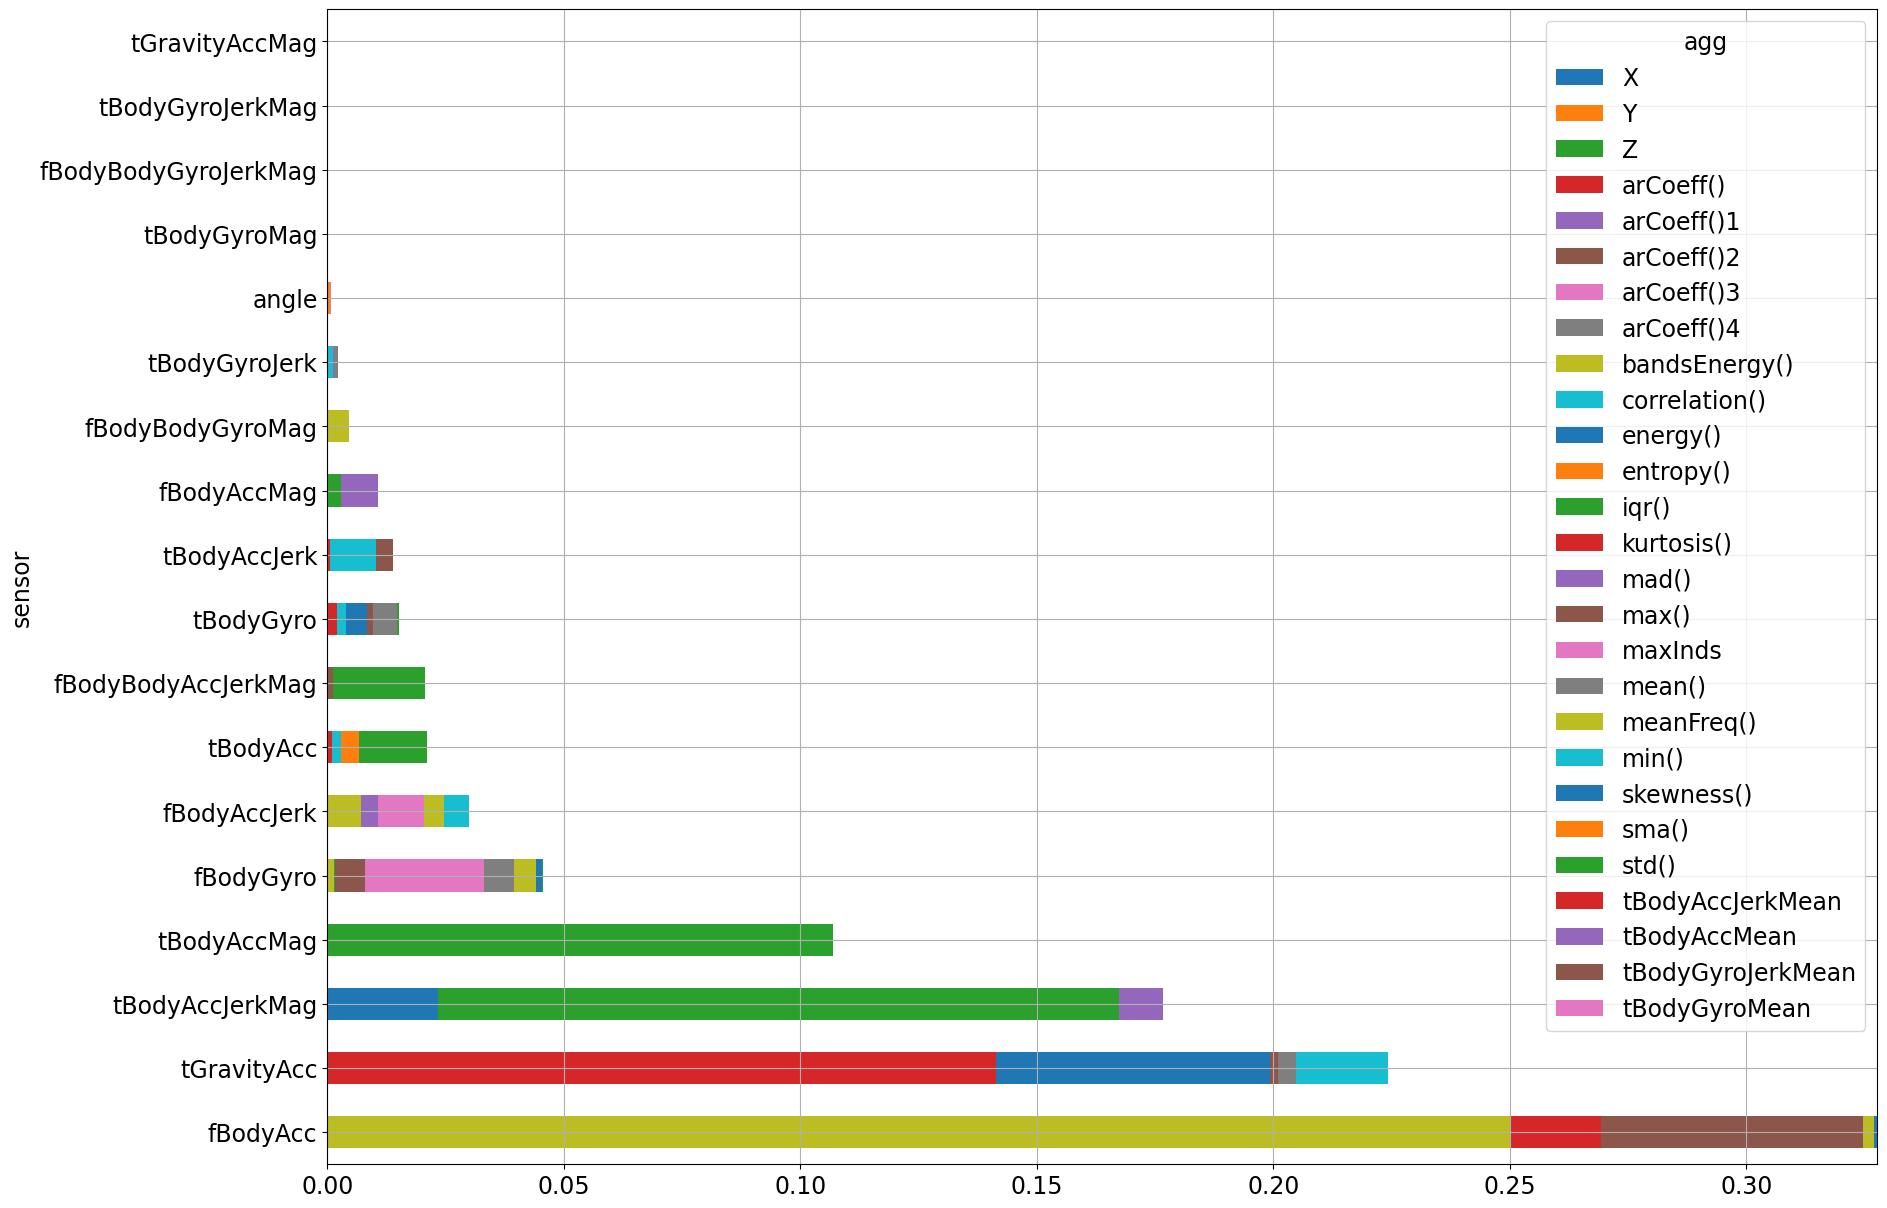

In [ ]:
# pandas의 plot 함수을 사용하여 acc를 sensor 별 agg 누적 수평그래프로 시각화
# 참고함수: 변수명.plot
# 파라미터: kind='barh', stacked=True, figsize=(20,15)



* 결과 저장

In [ ]:
# result_comp 변수에 result 데이터프레임의 data, model_name을 컴럼으로 지정 후 할당
# 참고함수: set_index
# 지정 인덱스: ['data','model_name']


accuracy_score  f1_score
data  model_name                          
train svc               0.968839  0.971715
      knn               0.954674  0.958345
      lr                0.983003  0.984583
      gb                0.982436  0.983649
      xgb               0.990368  0.991052
      xgb_hpt           0.991501  0.992355
      xgb95_hpt         0.992068  0.992371
      xgb50_hpt         0.988669  0.988601
      xgb_top           0.992635  0.993060
test  xgb_hpt           0.963801  0.963447
      xgb_top           0.970588  0.970313
      up_xgb            0.986425  0.975113
      up_xgb_top        0.993213  0.987625

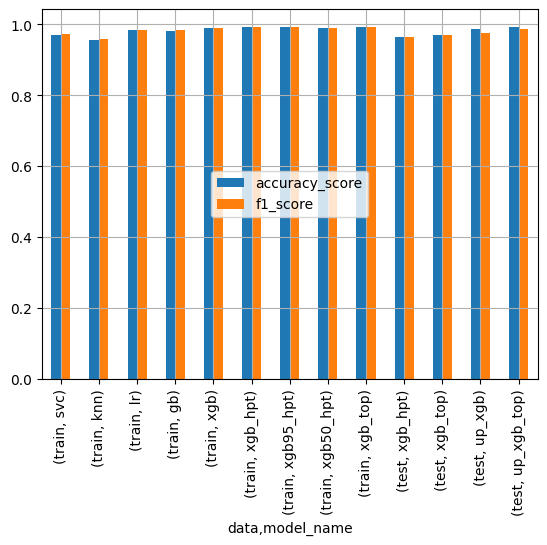

In [ ]:
# pandas의 plot 함수을 사용하여 AI모델 별 accuracy_score, f1_score 수직 그래프 시각화
# grid 추가
# legend 위치 center


In [ ]:
# 최종 result 데이터프레임 csv 파일로 저장
# 저장경로: ./
# 파일명: model_result.csv


---
---

<도전미션> 단말기 개발팀에서 최근에 수집한 real 데이터를 보내 주었습니다. 이 데이터에는 Activity 정보가 없습니다. 'subject' 열 기준 몇 번이 'WALKING_UPSTAIRS' 데이터인지 분류해서 말기 개발팀에 보내 주세요.

* Activity 표기가 없는 실제 데이터를 사용한 분류 예측

In [ ]:
# real_data.csv 파일을 불러와서 real_all 변수에 할당
# 잘 할당 되었는지 상위 5개행 데이터 확인



,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
0,0.064073,-0.005123,-0.271555,-0.231952,0.593444,0.833666,-0.293844,0.603777,0.906303,-0.203098,...,-0.317461,-0.703020,0.075952,-0.648670,-0.838078,0.407393,-0.327642,0.312526,0.431085,1
1,-0.239103,-0.096904,0.148035,-0.637325,-0.127692,-0.258924,-0.643642,-0.138551,-0.239634,-0.878149,...,-0.157009,-0.561918,0.002418,-0.002366,-0.101878,0.543207,0.378792,-0.488443,-0.487057,2
2,-0.181394,0.324130,0.129390,-0.867258,-0.581496,-0.777242,-0.885160,-0.575035,-0.748065,-0.971348,...,-0.528134,-0.884218,0.106616,0.579102,0.082680,-0.075495,-0.638803,-0.024623,-0.208879,3
3,-0.166426,-0.119353,0.133035,-0.633135,-0.189775,-0.319336,-0.623804,-0.199675,-0.281088,-0.925208,...,0.196038,-0.128895,0.139475,0.039216,-0.495303,0.082696,0.272083,-0.534122,-0.397428,4
4,-0.161088,-0.028160,-0.209931,0.817104,0.873037,0.127390,0.734566,0.845695,0.111837,0.803192,...,-0.609554,-0.864934,0.621322,-0.820087,0.351063,0.193917,-0.729349,0.208647,0.174249,5


In [ ]:
# real_fil 변수에 real_all 변수(데이터셋)에서 행동분류에 불필요한 'subject'열 제거한 데이터 할당
# 'subject'열이 잘 제거 되었는지 확인
# 나중에 예측 결과를 real_all 데이터 프레임 병합 해야 하므로 real_all 에서 'subject'열 제거하지 말것



,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.064073,-0.005123,-0.271555,-0.231952,0.593444,0.833666,-0.293844,0.603777,0.906303,-0.203098,...,-0.046164,-0.317461,-0.703020,0.075952,-0.648670,-0.838078,0.407393,-0.327642,0.312526,0.431085
1,-0.239103,-0.096904,0.148035,-0.637325,-0.127692,-0.258924,-0.643642,-0.138551,-0.239634,-0.878149,...,-0.691219,-0.157009,-0.561918,0.002418,-0.002366,-0.101878,0.543207,0.378792,-0.488443,-0.487057
2,-0.181394,0.324130,0.129390,-0.867258,-0.581496,-0.777242,-0.885160,-0.575035,-0.748065,-0.971348,...,-0.206895,-0.528134,-0.884218,0.106616,0.579102,0.082680,-0.075495,-0.638803,-0.024623,-0.208879
3,-0.166426,-0.119353,0.133035,-0.633135,-0.189775,-0.319336,-0.623804,-0.199675,-0.281088,-0.925208,...,-0.800684,0.196038,-0.128895,0.139475,0.039216,-0.495303,0.082696,0.272083,-0.534122,-0.397428
4,-0.161088,-0.028160,-0.209931,0.817104,0.873037,0.127390,0.734566,0.845695,0.111837,0.803192,...,0.458379,-0.609554,-0.864934,0.621322,-0.820087,0.351063,0.193917,-0.729349,0.208647,0.174249
5,-0.107530,0.013312,1.000000,-0.835146,-0.600036,-0.356636,-0.836418,-0.550924,-0.307091,-0.943929,...,-0.007533,-0.323623,-0.709580,0.142569,0.612084,-0.078512,0.002076,0.355207,-0.783544,0.169957
6,0.058595,-0.050059,-0.167108,-0.223698,0.110078,-0.094274,-0.248771,0.062721,-0.119843,-0.232788,...,0.486601,-0.477556,-0.801206,0.368073,0.435915,-0.935362,-0.041572,-0.506027,0.364035,0.229471
7,0.062631,-0.062839,-0.334600,-0.170677,-0.365133,0.099516,-0.210948,-0.404148,0.103444,0.092464,...,0.179968,0.207791,-0.149349,0.041817,0.121594,0.967539,-0.117698,-0.536821,0.207750,0.328708
8,0.069324,-0.007338,-0.161523,-0.090053,0.000301,0.243752,-0.232309,-0.026293,0.034870,0.321941,...,0.066485,-0.132151,-0.476123,0.669298,0.037212,0.906914,0.502852,-0.827640,0.155705,0.127148
9,-0.466440,-0.618098,0.948795,-0.789764,-0.057348,-0.352774,-0.803030,0.063835,-0.302126,-0.953206,...,0.008963,-0.399706,-0.728500,0.166498,0.611890,-0.002655,-0.018370,0.694861,-0.692058,-0.297937


In [ ]:
# x_real_top 변수에 학습에 필요한 Feature Slection 이 적용된 x_real 변수 할당
# Feature Select 된 상위 중요 feature 리스트는 importance_top 변수 사용



,"fBodyAcc-bandsEnergy()-1,8.1",tBodyAccJerkMag-iqr(),tBodyAccMag-std(),"tGravityAcc-arCoeff()-Z,3",tGravityAcc-energy()-Y,"fBodyAcc-bandsEnergy()-1,8",fBodyAcc-max()-X,"tGravityAcc-arCoeff()-X,1",fBodyGyro-maxInds-Z,tBodyAccJerkMag-energy(),...,fBodyBodyAccJerkMag-max(),tBodyAcc-entropy()-Z,"tBodyAcc-arCoeff()-X,2",tBodyGyro-energy()-Z,fBodyAcc-meanFreq()-Z,"tGravityAcc-arCoeff()-Y,4",tBodyGyroJerk-mean()-Z,fBodyAcc-skewness()-Y,"tBodyGyro-correlation()-X,Z","tBodyAccJerk-arCoeff()-Z,1"
0,0.511279,-0.057804,0.012607,-0.677887,-0.823021,-0.725428,-0.304987,-0.589778,-0.931034,-0.459842,...,-0.228427,0.172540,0.418793,0.015842,-0.244881,0.515458,0.306781,-0.299772,0.376800,-0.227992
1,-0.496576,-0.842448,-0.126678,-0.885667,0.008826,-0.910059,-0.553752,-0.890157,-1.000000,-0.971860,...,-0.670984,0.576139,0.310922,-0.923233,-0.686024,0.715991,-0.056614,-0.008266,0.284859,-0.545875
2,-0.869466,-0.945948,-0.544008,-0.880598,-0.916488,-0.987639,-0.845285,-0.862996,-1.000000,-0.996304,...,-0.939074,0.522255,0.432892,-0.928513,-0.508249,0.876901,0.060082,0.695521,-0.450511,-0.000068
3,-0.567425,-0.790722,0.064073,-0.895682,0.154649,-0.909014,-0.589863,-0.877100,-1.000000,-0.973438,...,-0.590491,0.356419,0.324892,-0.910792,-0.476125,0.741464,-0.056679,-0.234301,0.303823,-0.567292
4,0.040267,0.505935,0.513414,-0.254966,-0.950794,0.825165,0.425074,-0.633590,-0.655172,0.383505,...,0.026651,0.139892,0.011739,-0.275996,0.319899,0.306518,-0.175993,-0.581218,-0.263196,-0.109452
5,-0.880276,-0.957353,-0.355690,-0.979309,0.668201,-0.980620,-0.792201,-0.910529,-1.000000,-0.998097,...,-0.977546,1.000000,0.400040,-0.988971,-0.679306,0.783925,-0.033576,0.720642,0.611529,-0.069109
6,-0.340986,-0.473576,-0.285078,-0.710404,-0.713191,-0.626791,-0.204714,-0.780103,-0.931034,-0.796770,...,-0.643234,0.202014,0.316813,-0.549344,0.311948,0.649937,-0.384992,-0.316758,0.308641,-0.405777
7,-0.760381,-0.481433,-0.257473,-0.758603,-0.946843,-0.623527,-0.237941,-0.733029,-0.931034,-0.807032,...,-0.457396,-0.054653,0.111775,-0.732904,-0.154813,0.563945,-0.422386,-0.253915,0.286254,-0.763577
8,-0.538001,-0.152046,0.239322,-0.463740,-0.985843,-0.630435,-0.506080,-0.420639,-0.931034,-0.467029,...,0.186641,0.252837,0.109195,-0.733334,0.185990,0.234402,-0.254157,-0.439139,-0.155848,-0.313492
9,-0.359878,-0.909669,-0.739545,-0.937116,0.446198,-0.970950,-0.813602,-0.915979,-1.000000,-0.994718,...,-0.934448,0.950545,0.334966,-0.969974,-0.125004,0.782397,0.105496,0.727052,0.856723,0.027525


In [ ]:
# 위에서 생성해 놓은 up_xgb_top_model 모델으로 x_real_top 데이터의 'WALKING_UPSTAIRS' 행동분류 예측
# 예측결과 변수명: xgb_real_top_pred



array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0])

In [ ]:
# real_all['WALKING_UPSTAIRS'] 열에 up_xgb_top_pred 예측 결과를 할당



,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,WALKING_UPSTAIRS
0,0.064073,-0.005123,-0.271555,-0.231952,0.593444,0.833666,-0.293844,0.603777,0.906303,-0.203098,...,-0.703020,0.075952,-0.648670,-0.838078,0.407393,-0.327642,0.312526,0.431085,1,1
1,-0.239103,-0.096904,0.148035,-0.637325,-0.127692,-0.258924,-0.643642,-0.138551,-0.239634,-0.878149,...,-0.561918,0.002418,-0.002366,-0.101878,0.543207,0.378792,-0.488443,-0.487057,2,0
2,-0.181394,0.324130,0.129390,-0.867258,-0.581496,-0.777242,-0.885160,-0.575035,-0.748065,-0.971348,...,-0.884218,0.106616,0.579102,0.082680,-0.075495,-0.638803,-0.024623,-0.208879,3,0
3,-0.166426,-0.119353,0.133035,-0.633135,-0.189775,-0.319336,-0.623804,-0.199675,-0.281088,-0.925208,...,-0.128895,0.139475,0.039216,-0.495303,0.082696,0.272083,-0.534122,-0.397428,4,0
4,-0.161088,-0.028160,-0.209931,0.817104,0.873037,0.127390,0.734566,0.845695,0.111837,0.803192,...,-0.864934,0.621322,-0.820087,0.351063,0.193917,-0.729349,0.208647,0.174249,5,0
5,-0.107530,0.013312,1.000000,-0.835146,-0.600036,-0.356636,-0.836418,-0.550924,-0.307091,-0.943929,...,-0.709580,0.142569,0.612084,-0.078512,0.002076,0.355207,-0.783544,0.169957,6,0
6,0.058595,-0.050059,-0.167108,-0.223698,0.110078,-0.094274,-0.248771,0.062721,-0.119843,-0.232788,...,-0.801206,0.368073,0.435915,-0.935362,-0.041572,-0.506027,0.364035,0.229471,7,1
7,0.062631,-0.062839,-0.334600,-0.170677,-0.365133,0.099516,-0.210948,-0.404148,0.103444,0.092464,...,-0.149349,0.041817,0.121594,0.967539,-0.117698,-0.536821,0.207750,0.328708,8,0
8,0.069324,-0.007338,-0.161523,-0.090053,0.000301,0.243752,-0.232309,-0.026293,0.034870,0.321941,...,-0.476123,0.669298,0.037212,0.906914,0.502852,-0.827640,0.155705,0.127148,9,0
9,-0.466440,-0.618098,0.948795,-0.789764,-0.057348,-0.352774,-0.803030,0.063835,-0.302126,-0.953206,...,-0.728500,0.166498,0.611890,-0.002655,-0.018370,0.694861,-0.692058,-0.297937,10,0


In [ ]:
# 인덱스 미포함 real_all 변수를 real_result.csv 파일로 저장
# 저장경로: ./
# 파일명: real_result.csv



In [ ]:
# 저장 확인



,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,WALKING_UPSTAIRS
0,0.064073,-0.005123,-0.271555,-0.231952,0.593444,0.833666,-0.293844,0.603777,0.906303,-0.203098,...,-0.703020,0.075952,-0.648670,-0.838078,0.407393,-0.327642,0.312526,0.431085,1,1
1,-0.239103,-0.096904,0.148035,-0.637325,-0.127692,-0.258924,-0.643642,-0.138551,-0.239634,-0.878149,...,-0.561918,0.002418,-0.002366,-0.101878,0.543207,0.378792,-0.488443,-0.487057,2,0
2,-0.181394,0.324130,0.129390,-0.867258,-0.581496,-0.777242,-0.885160,-0.575035,-0.748065,-0.971348,...,-0.884218,0.106616,0.579102,0.082680,-0.075495,-0.638803,-0.024623,-0.208879,3,0
3,-0.166426,-0.119353,0.133035,-0.633135,-0.189775,-0.319336,-0.623804,-0.199675,-0.281088,-0.925208,...,-0.128895,0.139475,0.039216,-0.495303,0.082696,0.272083,-0.534122,-0.397428,4,0
4,-0.161088,-0.028160,-0.209931,0.817104,0.873037,0.127390,0.734566,0.845695,0.111837,0.803192,...,-0.864934,0.621322,-0.820087,0.351063,0.193917,-0.729349,0.208647,0.174249,5,0
5,-0.107530,0.013312,1.000000,-0.835146,-0.600036,-0.356636,-0.836418,-0.550924,-0.307091,-0.943929,...,-0.709580,0.142569,0.612084,-0.078512,0.002076,0.355207,-0.783544,0.169957,6,0
6,0.058595,-0.050059,-0.167108,-0.223698,0.110078,-0.094274,-0.248771,0.062721,-0.119843,-0.232788,...,-0.801206,0.368073,0.435915,-0.935362,-0.041572,-0.506027,0.364035,0.229471,7,1
7,0.062631,-0.062839,-0.334600,-0.170677,-0.365133,0.099516,-0.210948,-0.404148,0.103444,0.092464,...,-0.149349,0.041817,0.121594,0.967539,-0.117698,-0.536821,0.207750,0.328708,8,0
8,0.069324,-0.007338,-0.161523,-0.090053,0.000301,0.243752,-0.232309,-0.026293,0.034870,0.321941,...,-0.476123,0.669298,0.037212,0.906914,0.502852,-0.827640,0.155705,0.127148,9,0
9,-0.466440,-0.618098,0.948795,-0.789764,-0.057348,-0.352774,-0.803030,0.063835,-0.302126,-0.953206,...,-0.728500,0.166498,0.611890,-0.002655,-0.018370,0.694861,-0.692058,-0.297937,10,0


---
---